## Statistical Topography of the Dark Universe

### Imports & Definitions

In [1]:
# imports
import numpy as np
import pandas as pd
import seaborn as sns
import hdim_opt as hdim
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import warnings
import random
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from scipy.interpolate import griddata
from numpy.fft import fft2, fftshift, fftfreq
from scipy.stats import differential_entropy
from scipy.signal import find_peaks
from joblib import Parallel, delayed
from tqdm import tqdm
sns.set_style('dark')
sns.set_context("paper", font_scale=1.2, rc={
    "axes.titlesize": 17,
    "axes.labelsize": 15,
    "figure.titlesize": 18,
    "xtick.labelsize": 12.5,
    "ytick.labelsize": 12.5
})
plot_resolution = 'high'
history_path = 'spacetime_histories.csv'

### physical constants
epsilon = np.finfo(float).tiny
hbar = 1.0545718e-34 # hbar (SI)
C_SI = 299792458.0 # speed of light (m/s)
G_SI = 6.67430e-11 # gravitational constant (SI)
kappa_si = (8.0 * np.pi * G_SI) / (C_SI**4) # einstein coupling constant
t_planck = 5.391e-44 # planck time (SI)
l_planck = 1.616e-35 # planck length (SI)
m_planck = 2.176e-8 # kg
H_max = 1/t_planck # max expansion 1/s
rho_planck = 1e113 # planck energy limit
zeta_order = ['t','a','adot','adoubledot','phi','phidot','phidoubledot','mass_phi','k','beta','gamma']
zeta_order_si = ['t_si','a_si','adot_si','adoubledot_si','phi_si','phidot_si','phidoubledot_si','mass_si','k','beta','gamma']
plot_label_map = {'t': r'$t$', 'a': r'$a$', 'adot': r'$\dot{a}$', 'adoubledot': r'$\ddot{a}$', 
                  'phi': r'$\phi$', 'phidot': r'$\dot{\phi}$', 'phidoubledot': r'$\ddot{\phi}$', 'mass_phi': r'$m_{\phi}$', 
                  'k': r'$k$', 'beta': r'$\beta$', 'gamma': r'$\gamma$'
    }
formatted_labels = [plot_label_map.get(name, name) for name in zeta_order]

#### parameter space bounds #####

### physical constant exponents
log_tp = np.log10(t_planck)          # ~ -43.3 (Planck time)
log_lp = np.log10(l_planck)          # ~ -34.8 (Planck length)
log_mp = np.log10(m_planck)          # ~ -7.7  (Planck mass)
log_th = 18.0                        # ~ hubble age (seconds)
log_lh = 27.0                        # ~ Hubble Scale (meters)
log_mh = np.log10(hbar / (C_SI * 10**log_lh)) # ~ -69.0 (Compton/Hubble mass)

# derived first-order floors (velocity/flux): smallest length over largest time
log_v_floor = log_lp - log_th        # -34.8 - 18 = -52.8 (metric/field velocity floor)
log_v_ceil  = log_lh - log_tp        # 27.0 - (-43.3) = 70.3 (metric velocity ceiling)
log_phi_v_ceil = 65.0                # 65 for field flux to respect Planck energy limits (10^113)

# derived second-order floors (acceleration/dynamics): smallest velocity change over largest time
log_acc_floor = log_v_floor - log_th   # -52.8 - 18 = -70.8 (Acceleration Floor)
log_acc_ceil  = 113.0                  # Planck Acceleration limit

# scalar potential: field amplitude required to hit 10^-120 density at m_hubble
log_phi_floor = -34.0                # derived from rho_vac / m_hubble
log_phi_ceil  = 22.0                 # Planck energy field limit 10^113 rho_vac / m_planck

# ### strictly positive parameters
bounds_t    = (log_tp, log_th)       # s: Planck time to Hubble age
bounds_a    = (log_lp, log_lh)       # m: Planck length to Hubble scale
bounds_mass = (log_mh, log_mp)       # kg: compton mass to planck mass 

### symmetric parameters (range = |ceiling - floor|)
# kinematics
bounds_adot       = (-(log_v_ceil - log_v_floor), (log_v_ceil - log_v_floor)) # m/s: ceiling 70, floor -52 -> range = 122
bounds_adoubledot = (-(log_acc_ceil - log_acc_floor), (log_acc_ceil - log_acc_floor)) # m/s^2: ceiling 113, Floor -70 -> range = 183

# field dynamics
bounds_phi          = (-(log_phi_ceil - log_phi_floor), (log_phi_ceil - log_phi_floor)) # sqrt(J/m): ceiling 22, floor -34 -> range = 56
bounds_phidot       = (-(log_phi_v_ceil - log_v_floor), (log_phi_v_ceil - log_v_floor))  # sqrt(J/m)/s: ceiling 65, floor -52 -> range = 117
bounds_phidoubledot = (-(108.0 - log_acc_floor), (108.0 - log_acc_floor)) # sqrt(J/m)/s^2: Cciling 108, floor -70 -> range = 178

# linear bounds
bounds_k = (-1.0, 1.0)   # unitless curvature
bounds_beta = (-1.0, 1.0)   # kinetic polarity
bounds_gamma = (-1.0, 1.0)   # vacuum polarity

### define bounds
bounds = [bounds_t, bounds_a, bounds_adot, bounds_adoubledot,
          bounds_phi, bounds_phidot, bounds_phidoubledot, bounds_mass, bounds_k, 
          bounds_beta, bounds_gamma]
n_dim = len(bounds)

### define span for objective function 
lower_bounds = np.array([b[0] for b in bounds])
upper_bounds = np.array([b[1] for b in bounds])
span = upper_bounds - lower_bounds
buffer = hbar/2 * span

## Analysis Functions

In [2]:
def physical_statistics(ensemble_exponents):
    '''
    Main statistical analysis of ensemble.
    '''

    ##### preprocess #####
    df = analyze_coordinate(ensemble_exponents)
    df['probability'] = np.exp(df['probability'])
    total_count = len(df)

    # regime stats for plot annotation
    regime_stats = {'intensity': {}, 'probability': {}}
    for metric in ['intensity', 'probability']:
        temp_map = {}
        for reg in df['regime'].unique():
            r_mask = (df['regime'] == reg)
            r_count = np.sum(r_mask)
            if r_count > 0:
                r_typical = df.loc[r_mask, metric].median() # median value
                temp_map[reg] = r_typical * r_count
        
        # normalize to 100%
        total = sum(temp_map.values())
        regime_stats[metric] = {k: (v / total) * 100 for k, v in temp_map.items()}
    
    ##### plot distributions #####
    
    ### plot
    fig, axes = plt.subplots(2, 2, figsize=(16, 12.5))
    plot_configs = [
        (0, 0, 'beta', 'intensity',   r'Resonance'),
        (0, 1, 'beta', 'probability', r'Probability'),
        (1, 0, 'gamma', 'intensity',  r'Resonance'),
        (1, 1, 'gamma', 'probability', r'Probability')
    ]
    palette = {
        'Canonical': 'cornflowerblue',
        'Phantom': 'crimson',
        'Hybrid': 'orange'
    }

    # iterate through plot configs
    df.rename(columns={'regime':'Regime'},inplace=True)
    for row, col, var, w_col, title_prefix in plot_configs:
        ax = axes[row, col]

        sns.kdeplot(data=df, x=var, weights=df[w_col], hue='Regime', ax=ax, fill=True,
                    alpha=0.6, palette=palette, linewidth=2,
                    common_norm=False, cut=10, gridsize=1000)
        
        label_fancy = r'Kinetic Polarity $\beta$' if var == 'beta' else r'Vacuum Polarity $\gamma$'
        title_fancy = r'Kinetic' if var == 'beta' else r'Vacuum'
        ax.set_xlim(-1.33,1.33)
        ax.set_title(f'{title_prefix} ({title_fancy})')
        ax.set_xlabel(label_fancy)
        if w_col == 'intensity':
            ylabel = 'Intensity'
        else:
            ylabel = 'Density'
        ax.set_ylabel(ylabel)
        # ax.legend(fontsize=13)

    plt.tight_layout()
    fig.text(0.5, 0.98, r'Kinetic Phase $\beta$', ha='center', va='center', 
             fontsize=22, color='black')
    fig.text(0.5, 0.485, r'Vacuum Phase $\gamma$', ha='center', va='center', 
             fontsize=22, color='black')
    if plot_resolution == 'high':
        plt.savefig('plots/phase_comparison.png')
    plt.show()

    
    ##### display statistics #####
    # calculate species resonance and probability, for table
    unique_bodies = np.unique(df['species'])
    stats_list = []
    for body in unique_bodies:
        mask = (df['species'] == body)
        count = np.sum(mask)
        if count > 0:
            # Robust logic: Typical Weight * Population
            median_resonance = df.loc[mask, 'intensity'].median()
            resonance_proportion = median_resonance * count

            median_probability = df.loc[mask, 'probability'].median()
            probability_proportion = median_probability * count
            
            stats_list.append({
                'Species': body,
                'Resonance %': resonance_proportion,
                'Probability %': probability_proportion,
            })

    # create dataframe for table
    res_df = pd.DataFrame(stats_list)
    total_resonance = res_df['Resonance %'].sum()
    res_df['Resonance %'] = (res_df['Resonance %'] / total_resonance) * 100
    total_prob = res_df['Probability %'].sum()
    res_df['Probability %'] = (res_df['Probability %'] / total_prob) * 100
    res_df.sort_values(by='Probability %', ascending=False, inplace=True)
    
    print(f"\n- Topography Analysis")
    print(f"{'Species':<25} | {'Resonance %':<12} | {'Probability %':<12}")
    print("-" * 75)
    for _, row in res_df.iterrows():
        print(f"{row['Species']:<25} | {row['Resonance %']:<12.4f}% | {row['Probability %']:<12.4f}%")

    ##### latex table generation #####
    res_latex = res_df.to_latex(
        index=False,
        caption='Species and Regimes',
        label="tab:species_and_regimes",
        column_format='lrrr',
        float_format="%.4f"
    )

    stats_cols = ['t_si','a_si','adot_si','adoubledot_si','phi_si','phidot_si','phidoubledot_si','mass_si',
                  'k','beta','gamma','rho_kinetic','rho_potential','omega','H','nec']
    stats_df = df[stats_cols].copy()
    stats_df = stats_df.describe().loc[['50%','mean','std','min','max']].T
    stats_df.rename(columns={'50%':'Median','mean':'Mean','std':'Stdev.','min':'Min.','max':'Max.'},inplace=True)
    stats_df.index = list(plot_label_map.values()) + [r'$\rho_\text{k}$',r'$\rho_\text{v}$',r'$\omega$','$H$','NEC']
    
    stats_latex = stats_df.to_latex(
        index=True,
        caption='Ensemble Physical Statistics',
        label="tab:physical_statistics",
        column_format='lr|rr|rr',
        float_format="%.2e"
    )
    print()
    print(stats_latex)

    return res_df, stats_df

def diversity_statistics(ensemble_exponents):
    '''Quantify diversity of the ensemble.'''
    N = len(ensemble_exponents)

    ### normalized standard deviation (occupancy)
    dim_sds = np.std(ensemble_exponents, axis=0, ddof=1)
    norm_sds = dim_sds / span
    
    # standard error of the standard deviation (for a normal-ish distribution) is approx sigma / sqrt(2N)
    dim_se = dim_sds / np.sqrt(2 * N) 
    norm_se = dim_se / span
    total_occupancy = np.sqrt(np.mean(norm_sds**2))
    total_occupancy_se = np.mean(norm_se) # average uncertainty across the 11-D space
    
    print(f'Occupancy: {total_occupancy:.3f} ± {total_occupancy_se:.6f}')
    
    ### normalized differential entropy
    # calculate standard error of the mean entropy across the 11 columns
    efficiencies = []
    for i, (a, b) in enumerate(bounds):
        h_actual = differential_entropy(ensemble_exponents.iloc[:, i])
        h_max = np.log(b - a)
        efficiencies.append(h_actual / h_max)

    efficiencies = np.array(efficiencies)
    norm_entropy = np.mean(efficiencies)
    entropy_se = np.std(efficiencies, ddof=1) / np.sqrt(len(efficiencies)) # standard error of the mean for entropy vector
    print(f"Differential Entropy: {norm_entropy:.2%} ± {entropy_se:.4%}")

    y = np.arange(len(zeta_order))  # y-axis positions
    height = 0.35

    # plot
    fig, ax = plt.subplots(figsize=(9, 6))
    
    rects1 = ax.barh(y - height/2, norm_sds, height, label='Std. Deviation', color='cornflowerblue', alpha=0.8)
    rects2 = ax.barh(y + height/2, efficiencies, height, label='Diff. Entropy', color='orange', alpha=0.8)
    
    ax.set_xlabel('Normalized Value')
    ax.set_title('Diversity')
    ax.set_yticks(y)
    ax.set_yticklabels(formatted_labels)
    ax.invert_yaxis()
    ax.legend()
    ax.set_xlim(0, 1.1)
    
    plt.tight_layout()
    plt.savefig('plots/diversity.png')
    plt.show()

    ensemble_stats = {'total_occupancy':total_occupancy, 'norm_entropy':norm_entropy, 'efficiencies':efficiencies}
    
    return ensemble_stats

def peak_probabilities(probability_distribution_1d, ensemble_iso_1d):
    '''
    Analyzes peaks of the 1D PCA distribution.
    '''
    ### get peaks and amplitudes
    peaks, _ = find_peaks(probability_distribution_1d[1], height=0.15, prominence=0.001)
    peak_x_values = probability_distribution_1d[0][peaks].flatten()
    peak_heights = probability_distribution_1d[1][peaks] * 100 
    
    halfway = (len(peak_x_values) + 1) // 2
    left_x, right_x = peak_x_values[:halfway], peak_x_values[halfway:]
    left_p, right_p = peak_heights[:halfway], peak_heights[halfway:]
    
    ### latex table
    print(r"\begin{table}[p]")
    print(r"\centering")
    print(r"\caption{Principal Axis Peak Probabilities}")
    print(r"\scriptsize")
    print(r"\setlength{\tabcolsep}{3pt}")
    print(r"\begin{tabular}{rc w{c}{1.2em} S[table-format=-1.1] S[table-format=1.1e2] || rc w{c}{1.2em} S[table-format=-1.1] S[table-format=1.1e2]}")
    print(r"\toprule")
    h = r"\textbf{x} & \textbf{Prob.} & \textbf{Reg.} & \textbf{$\omega$} & \textbf{NEC}"
    print(f"{h} & {h} \\\\") 
    print(r"\midrule")
    
    for i in range(halfway):
        # helper for row lookup
        def get_row_data(x_val, p_val, is_right=False):
            mask = np.abs(ensemble_iso_1d.flatten() - x_val) < 0.1
            subset = df_physics[mask]
            
            prefix = ' & ' if is_right else ''
            if not subset.empty:
                w = subset['omega'].median()
                nec = subset['nec'].median()
                regime = subset['regime'].mode()[0][0] # Get first letter of mode
                
                # 4. Updated Row String: Removed Compactness (c)
                return f"{prefix}{x_val:.2f} & {p_val:.1f}\% & {regime}. & {w:.1f} & {nec:.1e}"
            else:
                return f"{prefix}{x_val:.2f} & {p_val:.1f}\% & ? & 0.0 & 0.0"

        # left side
        left_str = get_row_data(left_x[i], left_p[i])

        # right side
        if i < len(right_x):
            right_str = get_row_data(right_x[i], right_p[i], is_right=True)
        else:
            right_str = ' & & & & & '

        print(f"{left_str}{right_str} \\\\")
    
    print(r"\bottomrule")
    print(r"\multicolumn{10}{l}{\textit{Reg: C (Canonical), H (Hybrid), P (Phantom); $\omega$: Eq. of State; NEC: Null Energy Condition.}} \\")
    print(r"\end{tabular}")
    print(r"\end{table}")
    
    return peak_x_values, peaks

def sensitivity_lorentzian_wrapper(x_iso, ensemble, **unused_kwargs):
    '''
    x_iso: coordinates generated by the sensitivity analysis (isotropic).
    ensemble: isotropic ensemble.
    '''
    # map isotropic coordinates back to physical space
    x_raw = hdim.deisotropize(x_iso, iso_params)
    
    # calculate local bandwidth for these coordinates
    sigma_q_population = quantum_bandwidth(x_raw, iso_params['W_zca_inv'], norm_entropies)
    
    # evaluate KDE
    return hdim.lorentzian(x_iso, sigma_q_population, ensemble)

def sobol_distributions():
    print('\n############## sobol coordinates ##############\n')
    zeta_sobol = hdim.sobol(2**15,bounds)
    sobol_results = analyze_coordinate(zeta_sobol) 
    sobol_intensities = sobol_results['intensity']
    sobol_probabilities = sobol_results['probability']
    
    fig, ax = plt.subplots(1,2,figsize=(12,6))
    
    ax[0].hist(sobol_intensities, color='crimson', bins=100, alpha=0.9)
    ax[0].set_xlabel('')
    ax[0].set_ylabel('')
    ax[0].set_yscale('log')
    ax[0].set_yticks([])
    ax[0].set_xticks([-1000,-800,-600,-400,-200,0])
    ax[0].set_xlim(-1000,0)
    ax[0].tick_params(axis='both', which='major', labelsize=12.5, width=1.5, length=6)
    ax[0].set_ylabel('Frequency')
    ax[0].set_title('Sobol Intensity Distribution')
    
    ax[1].hist(df_physics['intensity'],color='cornflowerblue',bins=100)
    ax[1].set_xlabel('')
    ax[1].set_xlim(df_physics['intensity'].min(),df_physics['intensity'].max())
    ax[1].set_yticks([])
    ax[1].set_title('Ensemble Resonance Distribution')
    ax[1].tick_params(axis='both', which='major', labelsize=12.5, width=1.5, length=6)
    
    fig.supxlabel('Resonance',fontsize=15)
    
    plt.tight_layout()
    plt.show()
    
    # probability plot
    fig, ax = plt.subplots(1,2,figsize=(12,6))
    
    ax[0].hist(sobol_probabilities, color='crimson', bins=100, alpha=0.9)
    ax[0].set_xlabel('')
    ax[0].set_ylabel('')
    ax[0].set_ylabel('Frequency')
    ax[0].set_title('Sobol Probabilities')
    
    ax[1].hist(df_physics['probability'],color='cornflowerblue',bins=100)
    ax[1].set_xlabel('')
    ax[1].set_yticks([])
    ax[1].set_title('Ensemble Probabilities')
    
    fig.supxlabel('Probability (log)',fontsize=16)
    
    plt.tight_layout()
    if plot_resolution == 'high':
        plt.savefig('plots/probability_histogram.png')
    plt.show()

def spectral_analysis(ensemble_exponents, metric):
    '''SRT spectral analysis.'''

    # derive physical metrics
    df_physics = analyze_coordinate(ensemble_exponents)
    resolution = 2**13 if plot_resolution == 'high' else 2**8

    # 2D PCA
    pca2d = PCA(n_components=2)
    ensemble_iso_2d = pca2d.fit_transform(ensemble_isotropic)
    
    # PCA limits
    pc1_vec = np.linspace(ensemble_iso_2d[:, 0].min(), ensemble_iso_2d[:, 0].max(), resolution)
    pc2_vec = np.linspace(ensemble_iso_2d[:, 1].min(), ensemble_iso_2d[:, 1].max(), resolution)
    
    # calculate specific bounds and grid spacing
    pc1_min, pc1_max = ensemble_iso_2d[:, 0].min(), ensemble_iso_2d[:, 0].max()
    pc2_min, pc2_max = ensemble_iso_2d[:, 1].min(), ensemble_iso_2d[:, 1].max()
    
    pc1_vec = np.linspace(pc1_min, pc1_max, resolution)
    pc2_vec = np.linspace(pc2_min, pc2_max, resolution)
    PC1_grid, PC2_grid = np.meshgrid(pc1_vec, pc2_vec)
    
    # dx is the sample spacing (for physical wavenumber scaling)
    dx = (pc1_max - pc1_min) / (resolution - 1)
    freqs = fftshift(fftfreq(resolution, d=dx))
    
    ### helper functions
    def radial_profile(data):
        '''Compute 1D radial average of a 2D spectrum.'''
        y, x = np.indices(data.shape)
        center = np.array([(x.max()-x.min())/2.0, (y.max()-y.min())/2.0])
        r = np.sqrt((x - center[0])**2 + (y - center[1])**2).astype(int)
        tbin = np.bincount(r.ravel(), data.ravel())
        nr = np.bincount(r.ravel())
        return tbin / nr
    
    def get_beta_grid(mask, ensemble_iso_2d, df_physics, PC1_grid, PC2_grid, res, metric):
        '''Interpolate physics data onto the PCA manifold grid.'''
        if not np.any(mask): return np.zeros((res, res))
        pts = ensemble_iso_2d[mask, :2]
        vals = df_physics[metric].values[mask]
        grid = griddata(pts, vals, (PC1_grid, PC2_grid), method='cubic', fill_value=0)
        return grid.reshape(res, res)
    
    def calculate_psd_2d(grid):
        '''Compute normalized 2D Power Spectral Density.'''
        # normalize by std dev to focus on structural fluctuations
        fluct = (grid - np.mean(grid)) / (np.std(grid) + epsilon)
        return np.abs(fftshift(fft2(fluct)))**2
    
    ### preprocessing
    # split ensemble data by phase
    canonical_mask = (df_physics['regime'] == 'Canonical').values
    phantom_mask = (df_physics['regime'] == 'Phantom').values
    hybrid_mask = (df_physics['regime'] == 'Hybrid').values
    
    # generate grids
    grid_beta_canonical = get_beta_grid(canonical_mask, ensemble_iso_2d, df_physics, PC1_grid, PC2_grid, resolution, metric)
    grid_beta_phantom = get_beta_grid(phantom_mask, ensemble_iso_2d, df_physics, PC1_grid, PC2_grid, resolution, metric)
    grid_beta_hybrid = get_beta_grid(hybrid_mask, ensemble_iso_2d, df_physics, PC1_grid, PC2_grid, resolution, metric)
    
    # 2D PSDs
    psd_2d_canonical = calculate_psd_2d(grid_beta_canonical)
    psd_2d_phantom = calculate_psd_2d(grid_beta_phantom)
    psd_2d_hybrid = calculate_psd_2d(grid_beta_hybrid)
    
    # 1D PSDs via radial averaging
    psd_1d_canonical = radial_profile(psd_2d_canonical)
    psd_1d_phantom = radial_profile(psd_2d_phantom)
    psd_1d_hybrid = radial_profile(psd_2d_hybrid)
    
    # create k indices matching the length of the radial profile
    k_idx = np.arange(len(psd_1d_canonical))
    max_k = len(psd_1d_canonical)
    fit_end = int(max_k * 0.8)  # index 2 up to 80% of the available signal to avoid edge noise
    fit_range = slice(2, fit_end) 
    
    # generate grid for overall data
    all_indices = np.arange(len(df_physics))
    grid_beta_full = get_beta_grid(all_indices, ensemble_iso_2d, df_physics, PC1_grid, PC2_grid, resolution, metric)
    psd_2d_full = calculate_psd_2d(grid_beta_full)
    psd_1d_full = radial_profile(psd_2d_full)
    
    # ensure enough valid data for polyfit using k_idx[fit_range]
    alpha_canonical = np.polyfit(np.log(k_idx[fit_range]), np.log(psd_1d_canonical[fit_range]), 1)[0]
    alpha_phantom = np.polyfit(np.log(k_idx[fit_range]), np.log(psd_1d_phantom[fit_range]), 1)[0]
    alpha_hybrid = np.polyfit(np.log(k_idx[fit_range]), np.log(psd_1d_hybrid[fit_range]), 1)[0]
    
    print(f'\nCanonical Alpha: {alpha_canonical:.2f} | Phantom Alpha: {alpha_phantom:.2f} | Hybrid Alpha: {alpha_hybrid:.2f}')
    
    
    ################ VISUALIZATION
    # 2D power spectrum
    fig, ax = plt.subplots(1,1,figsize=(8,6))
    vmin, vmax = np.percentile(psd_2d_full, 3), psd_2d_full.max()
    
    im = ax.imshow(
        psd_2d_full, 
        norm=LogNorm(vmin=vmin, vmax=vmax), 
        extent=[freqs.min(), freqs.max(), freqs.min(), freqs.max()], 
        cmap='magma', interpolation='bilinear'
    )
    plt.title(r'Spectral Resonance')
    plt.xlabel(r'Wavenumber ($PC_1$)')
    plt.ylabel(r'Wavenumber ($PC_2$)')
    plt.xticks([])
    plt.yticks([])
    cbar = plt.colorbar(im, ax=ax, fraction=0.045, pad=0.02)
    cbar.set_label(r'Exotic Intensity')
    
    plt.tight_layout()
    if plot_resolution == 'high':
        plt.savefig('plots/spectral_res.png')
    plt.show()

    
    ### 1D spectral comparison
    plt.figure(figsize=(8, 6))
    plt.loglog(psd_1d_canonical, color='cornflowerblue', lw=2, label=fr'Canonical ($\tau$ = {alpha_canonical:.2f})')
    plt.loglog(psd_1d_phantom, color='crimson', lw=2, label=fr'Phantom ($\tau$ = {alpha_phantom:.2f})')
    plt.loglog(psd_1d_hybrid, color='orange', lw=2, label=fr'Hybrid ($\tau$ = {alpha_hybrid:.2f})',alpha=0.5)
    
    plt.title(r'Spectral Resonance (1-D Avg.)')
    plt.xlabel(r'Wavenumber')
    plt.ylabel(r'Intensity')
    plt.xticks()
    plt.yticks()
    plt.legend(fontsize=12.5)
    plt.grid(True, which="both", ls=":", alpha=0.5)
    
    plt.tight_layout()
    if plot_resolution == 'high':
        plt.savefig('plots/spectral_comparison.png')
    plt.show()


    ### waveform reconstruction
    waveform_canonical = hdim.waveform(x=psd_2d_canonical[:,0],y=psd_2d_canonical[:,1],sample_rate=1e6,domain='freq',verbose=False)
    waveform_phantom = hdim.waveform(x=psd_2d_phantom[:,0],y=psd_2d_phantom[:,1],sample_rate=1e6,domain='freq',verbose=False)
    waveform_hybrid = hdim.waveform(x=psd_2d_hybrid[:,0],y=psd_2d_hybrid[:,1],sample_rate=1e6,domain='freq',verbose=False)
    plt.figure(figsize=(8.5,6))
    plt.plot(waveform_canonical[0]['time_s'],np.abs(waveform_canonical[0]['amplitude']), color='cornflowerblue', lw=2, label=r'Canonical', alpha=0.75)
    plt.plot(waveform_phantom[0]['time_s'],np.abs(waveform_phantom[0]['amplitude']), color='crimson', lw=2, label=r'Phantom', alpha=0.75)
    plt.title('Resonance Waveform Comparison')
    plt.xlabel(r'Temporal Phase',)
    plt.ylabel(r'Amplitude',)
    plt.xticks([])
    plt.yscale('log')
    plt.legend(fontsize=12.5)
    plt.tight_layout()
    if plot_resolution == 'high':
        plt.savefig('plots/waveform.png')
    plt.show()

def covariance_analysis(ensemble_exponents):
    '''Analyze covariance metrics.'''
    formatted_df = ensemble_exponents.rename(columns=plot_label_map)
    correlation_df = formatted_df.corr()
    mask_filtered = np.tril(np.ones_like(correlation_df, dtype=bool))
    
    plt.figure(figsize=(8,6))
    sns.heatmap(data=correlation_df, mask=mask_filtered, annot=True, fmt='.2f', cmap='magma', vmin=-1.0, vmax=1.0)
    plt.title('Ensemble Correlation Matrix')
    plt.yticks(rotation=0)
    plt.xticks()
    plt.gca().invert_yaxis()
    plt.ylabel('')
    plt.xlabel('')
    plt.tight_layout()
    plt.savefig('plots/correlations.png')
    plt.show()
    
    covariance_df = formatted_df.cov()
    covariance_latex = covariance_df.to_latex(
        index=True,
        caption='Ensemble Covariance Matrix',
        label="tab:covariance",
        column_format='l' + 'r' * len(covariance_df.columns),
        float_format="%.1f",
        escape=False,
        longtable=False
    )
    print(covariance_latex)
    return covariance_df

def plot_force_field(zeta_exp, res=6):
    beta_range = np.linspace(-1, 1, res)
    gamma_range = np.linspace(-1, 1, res)
    B, G = np.meshgrid(beta_range, gamma_range)
    
    # initialize grids
    force_mag_grid = np.zeros_like(B)
    for i in range(res):
        for j in range(res):
            z_step = zeta_exp.copy()
            z_step[9] = B[i, j]  # beta
            z_step[10] = G[i, j] # gamma
            
            # calculate scalar force
            force, _, _ = resonant_force(z_step)
            force_mag_grid[i, j] = np.linalg.norm(force[[9, 10]])

    # plotting
    fig, ax = plt.subplots(1, 1, figsize=(8, 6.5), layout='constrained', sharey=True)

    # cp = ax.contourf(B, G, grid, levels=67, cmap='magma') # ORIGINAL
    im = ax.imshow(force_mag_grid, extent=[-1, 1, -1, 1], cmap='magma', 
               origin='lower', interpolation='gaussian', aspect='auto')
    
    # ylabel for the left-hand plot (index 0)
    if i == 0:
        ax.set_ylabel(r'Vacuum Polarity $\gamma$', fontsize=22)
    
    ax.set_xticks([-1, 1])
    ax.set_yticks([-1, 1])
    
    # shared X-axis label for the entire figure
    ax.set_title('Probability Gradient', fontsize=16)
    ax.set_xlabel(r'Kinetic Polarity $\beta$', fontsize=14)
    ax.set_ylabel(r'Vacuum Polarity $\gamma$', fontsize=14)
    
    # colorbar on the right of the axis group
    cbar = fig.colorbar(im, ax=ax, ticks=[], fraction=0.046, pad=0.02)
    cbar.set_label(r'$\left\| \vec{F}_{(\beta,\gamma)} \right\|$')
    
    plt.savefig('plots/gradient.png')
    plt.show()

def asymmetric_deviation(data):
    low1, median1, high1 = np.percentile(data, [16, 50, 84])
    
    # calculate asymmetric distances
    minus_val1 = median1 - low1
    plus_val1 = high1 - median1
    
    print('Asymmetric Deviation:')
    print(f'- Median: {median1:.0f}')
    print(f'- Superscript (+): {plus_val1:.0f}')
    print(f'- Subscript (-): -{minus_val1:.0f}')

def pca_kde_accumulation(n_axes=11):
    '''Accumulates principal axes to see the overlap/evolution of probability density.'''
    
    ### extract parameters
    ensemble_isotropic = archive['ensemble']
    X_centered = (ensemble_exponents - iso_params['mean']) / iso_params['stdev']
    ensemble_zero = np.dot(X_centered, iso_params['W_zca_inv'])

    # initialize plot
    plt.figure(figsize=(10, 7))
    colors = plt.cm.viridis(np.linspace(0, 1, n_axes))

    ### iterate through PCA components
    accumulation_results = []
    for i in range(1, n_axes + 1):
        ### fit PCA's
        # isotropic PCA
        pca_iso = PCA(n_components=i)
        ensemble_iso_nd = pca_iso.fit_transform(ensemble_isotropic)

        # zero-phase PCA
        pca_zero = PCA(n_components=i)
        ensemble_zero_nd = pca_zero.fit_transform(ensemble_zero)
        
        # define limits based on 1st axis
        if i == 1:
            x_min, x_max = ensemble_zero_nd.min(), ensemble_zero_nd.max()
            x_range_1d = np.linspace(x_min, x_max, plot_points_1d).reshape(-1, 1)

        ### calculate probabilities
        target_points_nd = np.zeros((plot_points_1d, i))
        target_points_nd[:, 0] = x_range_1d.flatten() 
        log_P_nd = hdim.lorentzian(target_points_nd, sigma_q_ensemble, ensemble_iso_nd, 
                                   eff_dim=i, estimator='pointwise', verbose=False)
        prob_nd = np.exp(log_P_nd)
        prob_nd /= np.max(prob_nd)
        
        ### plot
        alpha = 0.3 if i < n_axes else 0.8
        lw = 1 if i < n_axes else 3
        label = f'PC 1-{i}' if i % 2 != 0 or i == n_axes else None

        accumulation_results.append(prob_nd)
        plt.plot(x_range_1d.flatten(), prob_nd, color=colors[i-1], lw=lw, alpha=alpha, label=label)

    # plot parameters
    plt.title(f"Accumulated Probability Density (PCA)") # PCA 1 and PCA 1-11 same shape, different resolution
    plt.xlabel(r"Primary Principal Axis ($PC_1$)")
    plt.ylabel("Normalized Density")
    plt.legend(loc='upper right', fontsize='small', ncol=2)
    plt.xlim(-3.5, 3.5)
    plt.ylim(0, 1.1)
    plt.grid(axis='y', alpha=0.2)
    plt.tight_layout()
    
    if plot_resolution == 'high':
        plt.savefig('plots/kde_accumulation_11d.png')
    plt.show()

    return accumulation_results

def plot_energy_scatter():
    kin = np.arcsinh(df_physics['rho_kinetic'])
    vac = np.arcsinh(df_physics['rho_potential'])
    a = np.arcsinh(df_physics['a_si'])
    phi = np.arcsinh(df_physics['phi_si'])
    
    fig, ax = plt.subplots(1,2,figsize=(12,5.5))
    
    ax0 = ax[0].scatter(kin, vac, c=a, s=15, alpha=1)
    ax[0].set_xticks([-200,-100,100,200])
    ax[0].set_yticks([-200,-100,100,200])
    ax[0].set_ylabel('Potential Energy (arcsinh)',fontsize=16)
    ax[0].set_title(r'Scale Factor ($a$)',fontsize=18)
    fig.colorbar(ax0, ax=ax[0])
    
    ax1 = ax[1].scatter(kin, vac, s=5, c=phi, alpha=1)
    ax[1].set_xticks([-200,-100,100,200])
    ax[1].set_yticks([])
    ax[1].set_title(r'Scalar Field Density $(\phi)$',fontsize=18)
    fig.colorbar(ax1, ax=ax[1])
    
    fig.supxlabel('Kinetic Energy (arcsinh)',fontsize=16)
    
    plt.tight_layout()
    plt.savefig('plots/energy_metrics.png')
    plt.show()

## Main Functions

In [3]:
def obj_func(Y_pop_matrix, evolution=False):
    Y = np.atleast_2d(Y_pop_matrix)

    def residual_penalty_evolution(lhs, rhs, evolution=False):
        log_lhs = np.log10(np.abs(lhs) + epsilon) # epsilon ~= 10^-308
        log_rhs = np.log10(np.abs(rhs) + epsilon)
        mag_diff = np.abs(log_lhs - log_rhs)
        sign_mismatch = (np.sign(lhs) != np.sign(rhs))
        
        if evolution:
            sign_penalty = sign_mismatch.astype(float) * 1000 # sign penalty: base 10, higher than any exponent range
            penalty = mag_diff + sign_penalty
        else:
            action_gap = np.abs(log_lhs + log_rhs)
            penalty = np.where(sign_mismatch, action_gap, mag_diff)
            
        return penalty
    
    # boundary penalty
    dist_to_low = np.maximum(Y - lower_bounds, epsilon)
    dist_to_high = np.maximum(upper_bounds - Y, epsilon)
    penalty_low = np.log(np.clip(dist_to_low / buffer, epsilon, 1.0))
    penalty_high = np.log(np.clip(dist_to_high / buffer, epsilon, 1.0))
    bound_penalty_sum = -np.sum(penalty_high + penalty_low, axis=1)
    
    # physical residuals
    phys = evaluate_ensemble(Y)
    res_efe = residual_penalty_evolution(phys['efe_lhs'], phys['efe_rhs'], evolution)
    res_acc = residual_penalty_evolution(phys['acc_lhs'], phys['acc_rhs'], evolution)
    res_kg  = residual_penalty_evolution(phys['kg_lhs'],  phys['kg_rhs'], evolution)
    res_boundary = bound_penalty_sum if evolution else 0.0

    # total penalty
    penalty = res_efe + res_kg + res_acc + res_boundary

    # for debugging
    global penalty_dict
    penalty_dict = {'res_efe':np.median(res_efe), 'res_kg':np.median(res_kg), 'res_acc':np.median(res_acc),
                     'res_boundary':np.median(res_boundary),}
    
    return penalty
    
def resonance_approx(a_dd_si, mass_si, k, beta, gamma):
    '''Symbolic approximation for resonance.'''
    ### lorentzian function
    def lor(x): return 1.0 / (1.0 + np.square(x))
    
    ### symmetric-encode and normalize
    mass = np.log10(mass_si) / bounds_mass[1]
    a_dd = encode_bipolar(a_dd_si, log_acc_floor) / bounds_adoubledot[1]

    ### analytic approximation
    raw_shape = ((-1/2)*(beta**2 + gamma**2 + k**2) + (1/3)*beta*(gamma-k) + lor(a_dd**4/mass))
    ups_analytical = (2 * np.pi) * (raw_shape - 3)
    
    return ups_analytical
    
def evaluate_ensemble(zeta_exponents, rho_em=0.0):
    '''
    Converts exponents to SI and calculates all physical properties.
    '''
    if isinstance(zeta_exponents, pd.DataFrame):
        zeta_exponents = zeta_exponents.values
    zeta_exponents = np.atleast_2d(zeta_exponents)

    def decode_bipolar(val, floor_log):
        sign = np.sign(val)
        # magnitude added to the floor (i.e. abs(-10) + (-60) = -50)
        exponent = np.abs(val) + floor_log
        return sign * (10**exponent)

    # standard log parameters (strictly positive)
    t, a, mass = 10**zeta_exponents[:,0], 10**zeta_exponents[:,1], 10**zeta_exponents[:,7]
    
    # bipolar params (symmetric about 0); target = 10**(zeta + Floor)
    adot         = decode_bipolar(zeta_exponents[:,2], log_v_floor)
    adoubledot   = decode_bipolar(zeta_exponents[:,3], log_acc_floor)
    phi          = decode_bipolar(zeta_exponents[:,4], log_phi_floor)
    phidot       = decode_bipolar(zeta_exponents[:,5], log_v_floor)
    phidoubledot = decode_bipolar(zeta_exponents[:,6], log_acc_floor)
    
    # linear params
    k, beta, gamma = zeta_exponents[:, 8], zeta_exponents[:, 9], zeta_exponents[:, 10]

    ### analytic resonance approximation
    approx_resonance = resonance_approx(adoubledot, mass, k, beta, gamma)
                                            
    # derive metrics
    H = adot / (a + epsilon) # Hubble parameter
    mu_natural = mass * (C_SI / hbar)
    mu_sq = (mu_natural**2)
    
    # energy densities
    rho_kinetic = beta * (0.5 * (phidot**2) / C_SI**2)  # effectively V = [sqrt(|\beta|) * i^[(1-beta)/2] * phidot]^2
    rho_potential = gamma * (0.5 * mu_sq * (phi**2))   # effectively V = [sqrt(|\gamma|) * i^[(1-gamma)/2] * mu * phi]^2
    rho_total = rho_kinetic + rho_potential + rho_em
    P_total = rho_kinetic - rho_potential + rho_em / 3.0

    # residuals
    efe_lhs = H**2 + (k * C_SI**2 / a**2)
    efe_rhs = (kappa_si * C_SI**2 / 3.0) * rho_total
    acc_lhs = adoubledot/a
    acc_rhs = -(kappa_si * C_SI**2 / 6.0) * (rho_total + 3.0*P_total)
    kg_lhs = beta * (phidoubledot + 3*H*phidot)
    kg_rhs = -(C_SI**2) * gamma * (mu_sq * phi)

    ### metrics
    action = (P_total * t * a**3)
    omega = P_total / (rho_total + epsilon) # equation of state
    nec = rho_total + P_total # null energy condition (J/m^3)
    
    ### store SI values
    si_data = {'efe_lhs': efe_lhs, 'efe_rhs':efe_rhs, 'kg_lhs':kg_lhs, 'kg_rhs':kg_rhs, 'acc_lhs':acc_lhs, 'acc_rhs':acc_rhs,
            'rho_total': rho_total, 'P_total':P_total, 'action':action, 'rho_kinetic':rho_kinetic, 'rho_potential':rho_potential,
            'omega':omega, 'nec':nec, 'H':H,
            't_si':t, 'a_si':a, 'adot_si':adot, 'adoubledot_si':adoubledot,
            'phi_si':phi, 'phidot_si':phidot, 'phidoubledot_si':phidoubledot, 'mass_si':mass,
            'k':k, 'beta':beta, 'gamma':gamma, 'approx_resonance':approx_resonance,}
    
    return si_data

def encode_bipolar(si_val, floor_log):
    '''Bipolar encoding for a single parameter.'''
    mag = np.abs(si_val) + epsilon
    sign = np.sign(si_val)
    return sign * (np.log10(mag) - floor_log)

def encode_zeta(zeta_si):
    '''Encodes SI zeta coordinates into bipolar-symmetric space.'''
    if isinstance(zeta_si, pd.DataFrame):
        zeta_si = zeta_si.values
    
    zeta_si = np.atleast_2d(zeta_si)
    zeta_exp = np.zeros_like(zeta_si, dtype=float) # initialize 

    # logarithmic parameters
    zeta_exp[:, 0] = np.log10(zeta_si[:, 0]) # t_si
    zeta_exp[:, 1] = np.log10(zeta_si[:, 1]) # a_si
    zeta_exp[:, 7] = np.log10(zeta_si[:, 7]) # mass_si

    # bipolar-symmetric parameters
    zeta_exp[:, 2] = encode_bipolar(zeta_si[:, 2], log_v_floor)
    zeta_exp[:, 3] = encode_bipolar(zeta_si[:, 3], log_acc_floor)
    zeta_exp[:, 4] = encode_bipolar(zeta_si[:, 4], log_phi_floor)
    zeta_exp[:, 5] = encode_bipolar(zeta_si[:, 5], log_v_floor)
    zeta_exp[:, 6] = encode_bipolar(zeta_si[:, 6], log_acc_floor)

    # linear parameters
    zeta_exp[:, 8:11] = zeta_si[:, 8:11]

    # verify against global bounds
    is_oob = (zeta_exp < lower_bounds) | (zeta_exp > upper_bounds)
    if np.any(is_oob):
        # print out-of-bound dimensions
        failed_dims = np.unique(np.where(is_oob)[1])
        print(f"Warning: Dimensions {failed_dims} contain values outside physical bounds.")
        
    return zeta_exp

def quantum_bandwidth(zeta_exp, W_matrix, norm_entropies, rho_em=0.0):
    '''
    Calculates the 11-D kernel bandwidths. 
    sigma_q represents the uncertainty hypervolume of the relativistic predictions.
    '''

    ##### convert to SI #####
    zeta_phys = evaluate_ensemble(zeta_exp, rho_em)
    t_si = zeta_phys['t_si']
    action_si = np.abs(zeta_phys['action'])
    
    ##### uncertainty propagation #####
    n_action_quanta = action_si / hbar
    n_time_quanta = t_si / t_planck

    # scalar uncertainty
    sigma_decoherence = 1 / (np.arcsinh(n_action_quanta) + hbar/2) # quantum decoherence
    sigma_diffusion = np.arcsinh(np.sqrt(n_time_quanta)) / n_dim # diffusive entropy
    sigma_q_unprojected = hbar/2 + (sigma_decoherence * sigma_diffusion) # total

    ##### isotropize #####
    u_matrix = np.tile(sigma_q_unprojected[:, np.newaxis], (1, n_dim)) * norm_entropies # scaled by entropy of each parameter; commented out for comparison
    sigma_q_vector = np.dot(u_matrix, W_matrix)
    sigma_q = np.linalg.norm(sigma_q_vector, axis=1)
    
    return sigma_q

def analyze_coordinate(zeta_exp, rho_em=0.0):
    '''
    Runs the full analysis on the zeta coordinate.
    Lorentzian kernels model a quantum field, widths dictated by uncertainty.
    '''
    
    ### extract values
    zeta_exp = np.atleast_2d(zeta_exp)
    W_zca_inv = iso_params['W_zca_inv'].T

    ### zero-phase projections for intensity & probability
    X_centered = (zeta_exp - iso_params['mean']) / iso_params['stdev'] # standard scale
    zeta_zero = np.dot(X_centered, W_zca_inv) # intensity (isotropic)
   
    ### resonance intensity
    sigma_q = quantum_bandwidth(zeta_exp, W_zca_inv, norm_entropies, rho_em).reshape(-1, 1)
    intensity = hdim.lorentzian(zeta_zero, sigma_q, ensemble_isotropic, verbose=False)

    ### probability
    tension = obj_func(zeta_exp)
    probability = intensity - tension
    
    ### SI values & classification
    zeta_si = evaluate_ensemble(zeta_exp)
    species, regime = classify_zeta(zeta_si)

    ### build results
    results = zeta_si.copy()
    results['intensity'], results['probability'], results['tension'] = intensity, probability, tension
    results['species'], results['regime'] = species, regime
    
    return pd.DataFrame(results)

def classify_zeta(zeta_phys):
    '''Classify zeta into its species and regime.'''
    
    ### extract parameters
    rho = np.atleast_1d(zeta_phys['rho_total'])
    P = np.atleast_1d(zeta_phys['P_total'])
    nec = np.atleast_1d(zeta_phys['nec'])
    omega = np.atleast_1d(zeta_phys['omega'])
    beta = np.atleast_1d(zeta_phys['beta'])
    gamma = np.atleast_1d(zeta_phys['gamma'])

    ### matter states
    # equation of state
    is_superluminal = (omega > 1.01)
    is_stiff        = (omega > 0.34) & (omega <= 1.01)
    is_radiation    = (omega > 0.32)  & (omega <= 0.34)
    is_matter       = (omega >= -0.01) & (omega <= 0.32)
    is_quintessence  = (omega > -0.99) & (omega < -0.01)
    is_dark_energy   = (omega >= -1.01) & (omega <= -0.99)
    is_phantom_fluid = (omega < -1.01)

    # exotic fluid
    is_exotic = (nec < 0)

    ### regime
    is_phantom = (beta < 0.0) & (gamma < 0.0)
    is_canonical = (beta > 0.0) & (gamma > 0.0)

    conditions = [
        is_exotic, # extreme geometry proxy
        is_superluminal, is_stiff, # high-pressure
        is_radiation, is_matter, # canonical
        is_quintessence, is_dark_energy, is_phantom_fluid, # negative pressure
    ]

    choices = [
        'Exotic Fluid',
        'Superluminal Fluid', 'Stiff Fluid', 
        'Radiation', 'Matter', 
        'Quintessence', 'Dark Energy', 'Phantom Fluid', 
    ]
    
    # define body type and regime
    species = np.select(conditions, choices, default="Quantum Anomaly")
    regime = np.select([is_phantom, is_canonical], ['Phantom', 'Canonical'], default='Hybrid')

    return species, regime

def pca_kde():
    '''Principal axes of the SRT.'''

    # isotropic ensemble
    ensemble_isotropic = archive['ensemble']
    
    ######### 1D PROBABILITY DISTRIBUTION #########
    ### isotropic baseline ensemble
    pca1d_iso = PCA(n_components=1)
    ensemble_iso_1d = pca1d_iso.fit_transform(ensemble_isotropic) 
    
    ### inverse zero-phase for probability query coordinates
    X_centered = (ensemble_exponents - iso_params['mean']) / iso_params['stdev'] # standard scale
    ensemble_zero = np.dot(X_centered, iso_params['W_zca_inv']) # for probability
    pca_zero = PCA(n_components=1)
    ensemble_zero_1d = pca_zero.fit_transform(ensemble_zero)
    
    # generate points to sample from the KDE
    x_range = np.linspace(ensemble_zero_1d.min(), ensemble_zero_1d.max(), plot_points_1d).reshape(-1, 1) # 100000 final
    
    # 1d probabilities
    log_P_1d = hdim.lorentzian(x_range, sigma_q_ensemble, ensemble_iso_1d, estimator='pointwise', verbose=False)
    probability_1d = np.exp(log_P_1d)
    probability_1d /= np.max(probability_1d)
    
    ######### 2D RESONANCE TOPOGRAPHY #########
    # PCA_2
    pca2d = PCA(n_components=2)
    ensemble_iso_2d = pca2d.fit_transform(ensemble_isotropic)
    pca_zero_2d = PCA(n_components=2)
    ensemble_zero_2d = pca_zero_2d.fit_transform(ensemble_zero)
    
    ### generate mesh grids for plots
    pc1_vec = np.linspace(ensemble_zero_2d[:, 0].min(), ensemble_zero_2d[:, 0].max(), plot_resolution_2d)
    pc2_vec = np.linspace(ensemble_zero_2d[:, 1].min(), ensemble_zero_2d[:, 1].max(), plot_resolution_2d)
    PC1_mesh, PC2_mesh = np.meshgrid(pc1_vec, pc2_vec)
    target_points = np.stack([PC1_mesh.ravel(), PC2_mesh.ravel()], axis=1)
    
    # 2d resonance intensities
    intensity_2d = hdim.lorentzian(target_points, sigma_q_ensemble, ensemble_iso_2d, eff_dim=2, estimator='pointwise', verbose=False)
    P_grid_pca = (intensity_2d).reshape(plot_resolution_2d, plot_resolution_2d)
    P_grid_pca -= P_grid_pca.min()
    P_grid_pca /= (P_grid_pca.max())

    # plot 1d
    plt.figure(figsize=(8, 6.25))
    plt.plot(x_range.flatten(), probability_1d, color='cornflowerblue', lw=2)
    plt.fill_between(x_range.flatten(), probability_1d, color='cornflowerblue', alpha=0.15)
    plt.title(f"Probability Density")
    plt.xlabel(r"Principal Axis $(PC_1)$")
    plt.ylabel("Density")
    plt.xticks([])
    plt.yticks([])
    plt.xlim(-3.33,3.33)
    plt.ylim(0,1.05)
    plt.tight_layout()
    if plot_resolution == 'high':
        plt.savefig('plots/kde_1d.png')
    plt.show()
    
    # plot 2D PCA
    plt.figure(figsize=(8,6.25))
    plt.contourf(PC1_mesh, PC2_mesh, P_grid_pca, levels=67, cmap='bone')
    plt.colorbar(label='', format="{x:.1f}", fraction=0.04, pad=0.015)
    plt.title('Resonance Intensity')
    plt.xlabel(r'Kinetic Axis $({PC_1})$')
    plt.ylabel(r'Vacuum Axis $({PC_2})$',)
    plt.xlim(-3.33,3.33)
    plt.ylim(-3.33,3.33)
    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()
    if plot_resolution == 'high':
        plt.savefig('plots/kde_2d.png')
    plt.show()

    ### PCA loadings
    loadings_1d = pd.DataFrame(pca_zero.components_.T, columns=['PC1'], index=zeta_order)
    loadings_2d = pd.DataFrame(pca2d.components_.T, columns=['PC1', 'PC2'], index=zeta_order)
    
    print(loadings_1d.round(3).to_markdown())
    print(loadings_2d.round(3).to_markdown())

    return (x_range, probability_1d), (P_grid_pca, intensity_2d), (ensemble_iso_1d, ensemble_zero_1d)

# expectation value
def expectation_value(df_physics):
    '''
    Calculates ensemble expectation value (zeta_0).
    '''
    # convert to array
    df = df_physics[zeta_order_si + ['probability']]
    zeta_matrix = df[zeta_order_si].values
    
    # extract log-probabilities
    log_probs = df['probability'].values.flatten()
    
    # normalize to max value to avoid numerical underflow
    normalized_log_probs = log_probs - np.max(log_probs)
    raw_probabilities = np.exp(normalized_log_probs)
    
    # total ensemble weight (partition function)
    Z = np.sum(raw_probabilities)
    
    # probability-weighted expectation value
    # zeta_0 = sum(zeta * P) / sum(P)
    zeta_0 = np.sum(zeta_matrix * raw_probabilities[:, np.newaxis], axis=0) / Z
    print('Ensemble expectation value (zeta_0):')
    for dim, val in zip(zeta_order_si, zeta_0):
        print(f'{dim:} : {val:.2e}')
    
    return zeta_0

# median probability of wormholes in our universe
def repolarize_species(species, beta=1.0, gamma=1.0):
    species_mask = (df_physics['species'] == species).values
    
    # filter the raw exponents
    species_ensemble = ensemble_exponents.iloc[species_mask].copy()

    # force the phase to (beta, gamma)
    species_ensemble['beta'] = beta
    species_ensemble['gamma'] = gamma
    
    # dual-zero phase projection
    results = analyze_coordinate(species_ensemble)

    # probability of tunneling into this phase
    return results

def action_barrier(zeta_start, zeta_end, n_steps=20):
    '''Energy to roll over the hill.'''
    ensemble_iso = archive['ensemble']
    path = np.linspace(zeta_start, zeta_end, n_steps)
    total_work = 0.0
    
    # normalize displacement
    dz = np.linalg.norm(zeta_end.values - zeta_start.values) / n_steps
    
    for i in range(len(path) - 1):
        z_mid = (path[i] + path[i+1]) / 2.0
        
        # force at midpoint
        force, _, _ = resonant_force(z_mid)
        
        # magnitude of the force along the path
        total_work += np.linalg.norm(force) * dz
        
    return total_work
    
def resonant_force(zeta_exp):
    '''Calculate the resonant force (probability gradient) of the coordinate. 
    Input can be zeta_exp or zeta_si, output accordingly.'''
    
    zeta_exp = np.atleast_2d(zeta_exp) # (1,11)
    n_dim = zeta_exp.shape[1]
    eps = 1 / (2 * np.pi)**11

    # create batch to perturbate
    perturb = np.eye(n_dim) * eps
    zeta_plus = zeta_exp + perturb
    zeta_minus = zeta_exp - perturb
    full_batch = np.vstack([zeta_plus, zeta_minus])

    # analyze batch coordinates
    batch_results = analyze_coordinate(full_batch)
    
    # differentiation
    r_all = batch_results['intensity'].values
    f_all = batch_results['tension'].values
    
    r_plus, r_minus = r_all[:n_dim], r_all[n_dim:]
    f_plus, f_minus = f_all[:n_dim], f_all[n_dim:]

    grad_res = (r_plus - r_minus) / (2 * eps)
    grad_phys = (f_plus - f_minus) / (2 * eps)
    net_force = grad_res - grad_phys # net force: ∇ ln P = ∇ Intensity - ∇ Tension
    return net_force, grad_res, grad_phys

def isotropize_zeta(zeta_exp):
    '''Transform the zeta coordinate to ensemble isotropic space.'''
    zeta_centered = (zeta_exp.flatten() - iso_params['mean']) / iso_params['stdev']
    W_zca = iso_params['W_zca']
    zeta_prime = np.dot(zeta_centered, W_zca)
    return zeta_prime
    
def fluctuation_analysis(zeta_source_exp, zeta_dest_exp, path_steps=100, verbose=True):
    '''
    Calculates action (S) via vector line integration and 
    fluctuation probability (T).
    '''
    # isotropize zeta
    zeta_source = isotropize_zeta(zeta_source_exp)
    zeta_dest = isotropize_zeta(zeta_dest_exp)

    # path calculations in isotropic space
    path = np.linspace(zeta_source, zeta_dest, path_steps)
    path_indices = np.linspace(0, 1, path_steps)
    dist = np.linalg.norm(zeta_dest - zeta_source)
    dz = dist / (path_steps - 1)
    
    force_norms = []
    h_profile = []
    potential_barrier = []
    
    for z in path:
        # deisotropize for objective and evaluation checks
        z_exp_temp = (z * iso_params['stdev']) + iso_params['mean']
        z_exp = np.dot(z_exp_temp, iso_params['W_zca_inv'])
        
        # scalar log-probability profile for plotting
        results = analyze_coordinate(z_exp)
        potential_barrier.append(results['tension'] - results['intensity'])
        
        # calculate local gradient
        net_force, _, _ = resonant_force(z_exp)
        force_norm = np.linalg.norm(net_force)
        force_norms.append(force_norm)
        
        # calculate local uncertainty bandwidth
        h_local = quantum_bandwidth(z_exp, iso_params['W_zca_inv'], norm_entropies)[0]
        h_profile.append(h_local)
    
    h_profile = np.array(h_profile).flatten()
    force_norms = np.array(force_norms).flatten()
    net_height = np.maximum(0, np.array(potential_barrier).flatten())

    # action integration
    local_action_density = force_norms / h_profile
    
    # integration via trapezoids
    delta_S = np.sum(local_action_density[:-1] + local_action_density[1:]) * 0.5 * dz

    # log probability: action / uncertainty
    log_probability = -delta_S
    
    # barrier peaks for plotting
    V_max = np.max(net_height)
    V_max_index = np.argmax(net_height)
    
    if verbose:
        fig, ax = plt.subplots(figsize=(8, 6.5))
        
        # fill and plot barrier using the scalar potential profile
        ax.fill_between(path_indices, 0, net_height, color='crimson', alpha=0.15)
        ax.plot(path_indices, net_height, color='crimson', linewidth=2.5)
        
        # endpoints
        ax.scatter([path_indices[0], path_indices[-1]], 
                   [net_height[0], net_height[-1]], 
                   color='cornflowerblue', marker='x', s=200, zorder=5)

        y_max = np.max(net_height) if np.max(net_height) > 0 else 1.0
        y_nudge = y_max * 0.05
        
        # labels
        ax.text(path_indices[0] + 0.01, net_height[0] + y_nudge, r'$\tilde{\zeta}_\mathcal{E}$', 
                ha='left', va='bottom', fontsize=20, color='black')
        ax.text(path_indices[-1] - 0.01, net_height[-1] + y_nudge, r'$\zeta_{\mathcal{E}}$', 
                ha='right', va='bottom', fontsize=20, color='black')
        
        ax.set_title('Topographic Fluctuation Barrier')
        ax.set_xlabel(r'Isotropic Distance ($\Delta \zeta$)')
        ax.set_ylabel(r'Effective Action ($S$)')
        
        ax.set_xlim([-0.05, 1.05])
        ax.set_ylim([0, y_max * 1.2])
        ax.set_xticks([0, 1])
        ax.set_xticklabels([])
        ax.grid(True, linestyle='--', alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('plots/tunneling_barrier.png')
        plt.show()

    return {
        'probability': log_probability,
        'barrier_volume_action': delta_S,
        'barrier_peak_height': V_max,
        'path_distance_isotropic': dist
    }

def obj_optimal_phase(phase,species):
    '''
    Unified objective: Finds the [beta, gamma] phase that maximizes 
    the Bayesian log-probability for the target species ensemble.
    '''
    beta, gamma = phase    
    results = repolarize_species(species,beta,gamma)
    probability_med = np.median(results['probability'])
    penalty = -probability_med

    return penalty
    
def find_natural_phase(species, n_iter):
    phase_bounds = np.array([[-1.0, 1.0], [-1.0, 1.0]]) # bounds for beta and gamma
    optimal_phases = []
    for i in range(0,n_iter):
        best_phase_coords, min_val = hdim.quasar(
                                        func=obj_optimal_phase,
                                        bounds=phase_bounds,
                                        args=(species,),
                                        popsize=2**3,
                                        maxiter=10,
                                        tolerance=hbar/2,
                                        vectorized=False,
                                        verbose=True,
                                        plot_solutions=False,
                                        num_to_plot=3,
                                        seed=i
                                    )
        optimal_phases += [best_phase_coords]
        print(f"\nTrial {i}: ({best_phase_coords[0]:.4f}, {best_phase_coords[1]:.4f})")
    
    optimal_phases = np.array(optimal_phases)
    phase_median = np.median(optimal_phases,axis=0)
    phase_error = np.std(optimal_phases,axis=0)/np.sqrt(len(optimal_phases))
    print(f'Optimal wormhole phase: {phase_median} ± {phase_error}')
 
    return phase_median, phase_error

## Evolutionary Optimization
- Uncomment to generate ensemble of spacetime coordinates

In [4]:
# # # define hyperparameters
# # n_points = 33300 # 2^15 + 1%; standard error 1/sqrt(N) of ~0.3%  
# # popsize = 2**n_dim # 2^11 = 1 point per vertex
# # maxiter = 1000*n_dim # 1000*n_dim = 11000 final; residuals < 1e-16;

# # # test hyperparameters
# n_points = 10 # testing number
# popsize = 2**11 # testing number
# maxiter = 11000 # testing number

# def run_single_simulation(seed_val):
#     '''Holds a single QUASAR task'''
#     # result = [final_params, final_fitness]
#     result = hdim.quasar(
#         obj_func,
#         bounds,
#         kwargs={'evolution':True}, # enables boundary penalty + boolean C_sign
#         popsize=popsize,
#         maxiter=maxiter,
#         tolerance=hbar/2,
#         vectorized=True,
#         polish=False,
#         verbose=False,
#         seed=seed_val
#     )
#     return result[0].reshape(1, n_dim), result[1]

# # number of cores (-1 uses all available cores)
# n_cores = -1 

# ########################### generate samples
# # parallel execution
# print(f'Running evolutionary optimization for {n_points} samples.')
# results = Parallel(n_jobs=n_cores)(
#   delayed(run_single_simulation)(i) for i in tqdm(range(n_points))
# )


# # results is a list of tuples: [(history, fitness)]
# all_histories, all_fitnesses = zip(*results)

# # stack and save histories
# ensemble_srt = np.vstack(all_histories)
# df_srt = pd.DataFrame(ensemble_srt, columns=zeta_order)
# df_srt['fitness'] = all_fitnesses
# df_srt.to_csv(history_path, index=False) # save to a separate test file

# # quick spatial analysis
# df_srt['a'].hist(bins=50)
# plt.title('"a" distribution')
# plt.show()

## KDE

Occupancy: 0.254 ± 0.000979
Differential Entropy: 94.04% ± 1.4891%


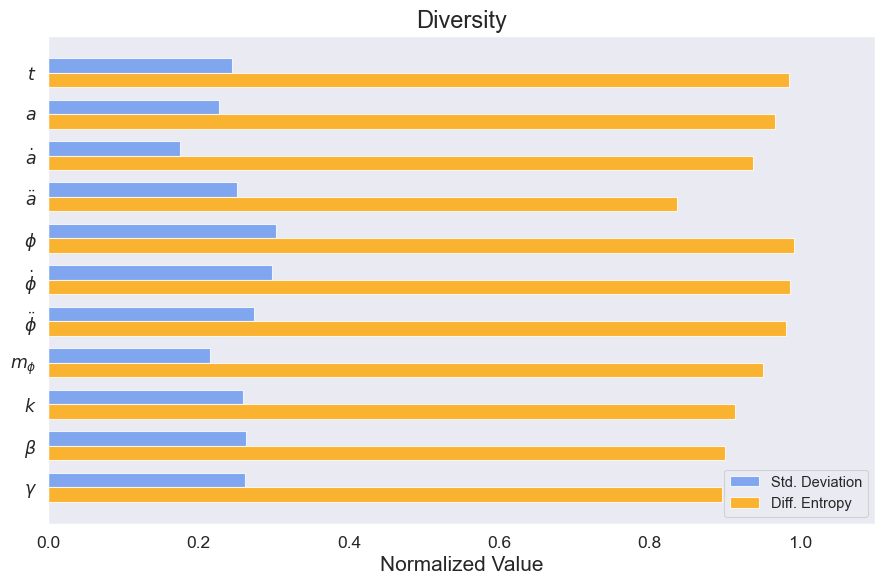

,efe_lhs,efe_rhs,kg_lhs,kg_rhs,acc_lhs,acc_rhs,rho_total,P_total,action,rho_kinetic,rho_potential,omega,nec,H,t_si,a_si,adot_si,adoubledot_si,phi_si,phidot_si,phidoubledot_si,mass_si,k,beta,gamma,approx_resonance,intensity,probability,tension,species,regime
0,7.797548e+02,7.797548e+02,2.542141e+38,2.542141e+38,7.797548e+02,7.797548e+02,1.253358e+29,-1.253358e+29,-6.858731e+57,3.427404e-28,1.253358e+29,-1.0,0.000000e+00,-8.594175e-07,2.265466e+08,6.227834e+06,-5.352309e+00,4.856183e+09,-8.862308e+07,-1.013541e-05,4.238827e+38,2.343991e-36,0.336504,0.599728,0.718804,-15.195451,-13.895476,-13.895476,1.421085e-14,Dark Energy,Canonical
1,5.349036e-12,5.349036e-12,-2.067764e+58,-2.067764e+58,5.349036e-12,5.349036e-12,8.597904e+14,-8.597904e+14,-8.979081e+13,1.195837e-102,8.597904e+14,-1.0,0.000000e+00,1.028882e-34,1.293351e-42,4.322227e+13,4.447059e-21,2.311975e+02,7.474170e-27,7.956728e-43,-6.090131e+58,3.732298e-09,0.111186,0.339527,0.273436,-13.090148,-17.302266,-17.302266,3.552714e-15,Dark Energy,Canonical
2,-2.108883e+31,-2.108883e+31,1.791240e+35,1.791240e+35,4.217766e+31,4.217766e+31,-3.389765e+57,-3.389765e+57,-1.608922e+30,-3.389765e+57,1.703701e-07,1.0,-6.779530e+57,1.845815e-02,2.390887e-06,5.833584e-08,1.076772e-09,2.460469e+24,-1.709664e-25,-1.883634e+38,-3.094027e-46,2.298005e-21,-0.798513,-0.017173,0.273156,-14.847879,-14.589993,-14.589993,1.421085e-14,Exotic Fluid,Hybrid
3,1.947682e+45,1.947682e+45,1.173398e+14,1.173398e+14,-3.895363e+45,-3.895363e+45,3.130654e+71,3.130654e+71,1.675083e+41,3.130654e+71,5.975396e-24,1.0,6.261308e+71,-1.837121e-31,2.179103e+13,2.906528e-15,-5.339644e-46,-1.132198e+31,-9.153614e-21,-2.643139e+44,1.792530e-21,1.956629e-34,0.183074,0.805501,0.461005,-14.911704,-14.791287,-14.791287,3.552714e-15,Stiff Fluid,Canonical
4,-1.561267e+27,-1.561267e+27,1.446576e+19,1.446576e+19,3.122535e+27,3.122535e+27,-2.509542e+53,-2.509542e+53,-1.062682e+08,-2.509542e+53,1.361367e+08,1.0,-5.019083e+53,3.738641e-17,3.475809e-29,2.301005e-06,8.602631e-23,7.184969e+21,-1.691630e+06,-3.497515e+35,1.466667e-39,4.608211e-45,-0.091975,-0.368762,0.554422,-14.485849,-15.156238,-15.156238,0.000000e+00,Exotic Fluid,Hybrid


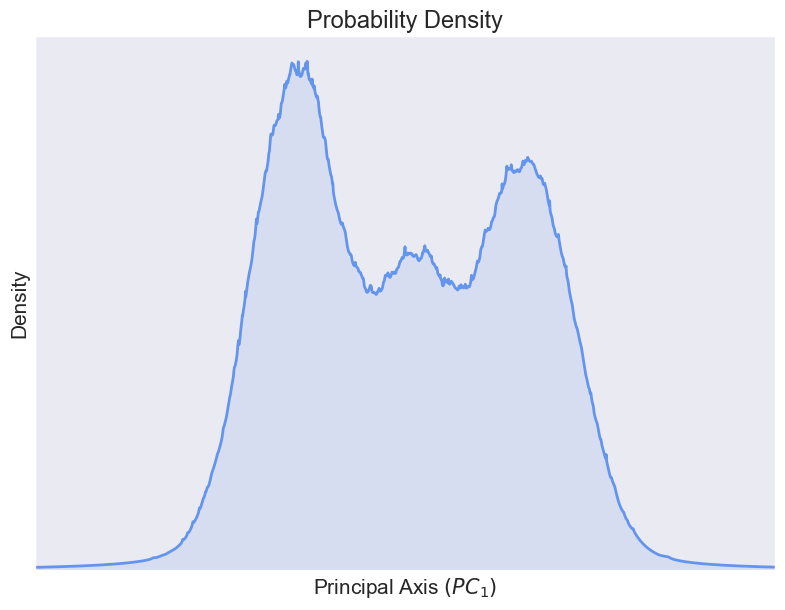

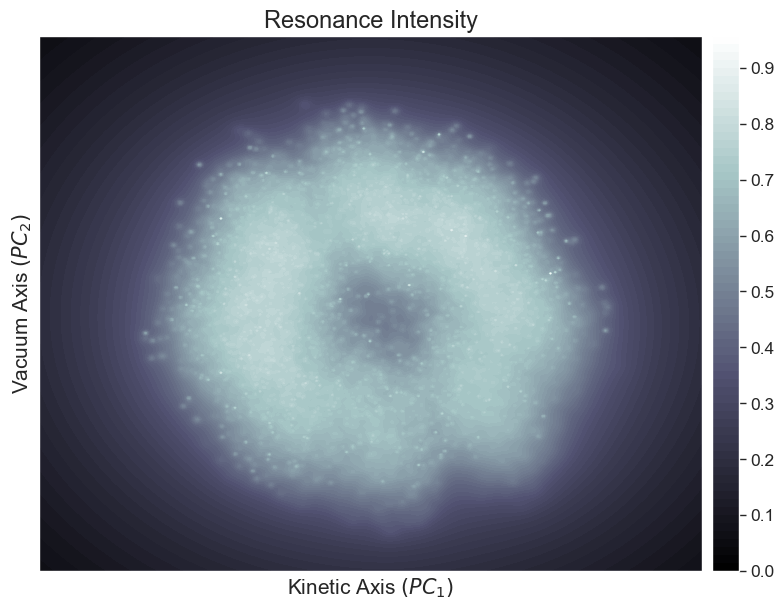

|              |    PC1 |
|:-------------|-------:|
| t            |  0.011 |
| a            | -0.019 |
| adot         | -0.011 |
| adoubledot   |  0.657 |
| phi          | -0.01  |
| phidot       |  0.018 |
| phidoubledot |  0     |
| mass_phi     | -0.012 |
| k            | -0.295 |
| beta         | -0.639 |
| gamma        |  0.269 |
|              |    PC1 |    PC2 |
|:-------------|-------:|-------:|
| t            |  0.012 | -0.035 |
| a            | -0.019 |  0.187 |
| adot         | -0.011 |  0.003 |
| adoubledot   |  0.647 |  0.254 |
| phi          | -0.006 |  0.006 |
| phidot       |  0.017 | -0.01  |
| phidoubledot | -0.001 | -0     |
| mass_phi     | -0.018 | -0.07  |
| k            | -0.32  |  0.622 |
| beta         | -0.647 |  0.198 |
| gamma        |  0.242 |  0.684 |

Canonical Alpha: -4.24 | Phantom Alpha: -5.60 | Hybrid Alpha: -4.38


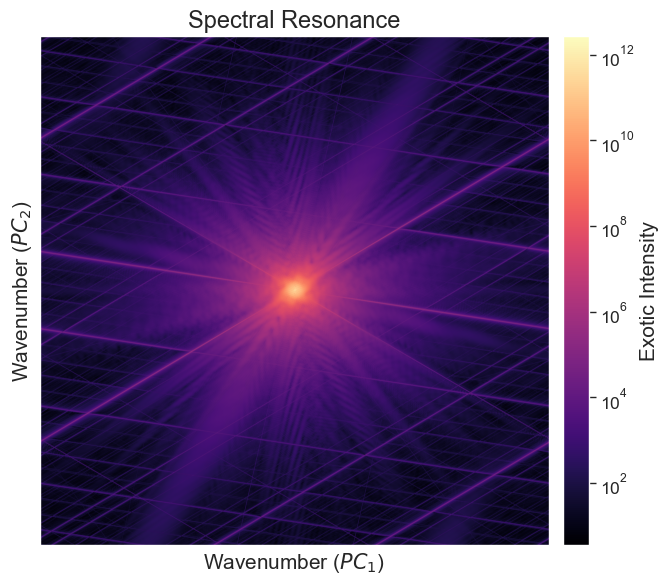

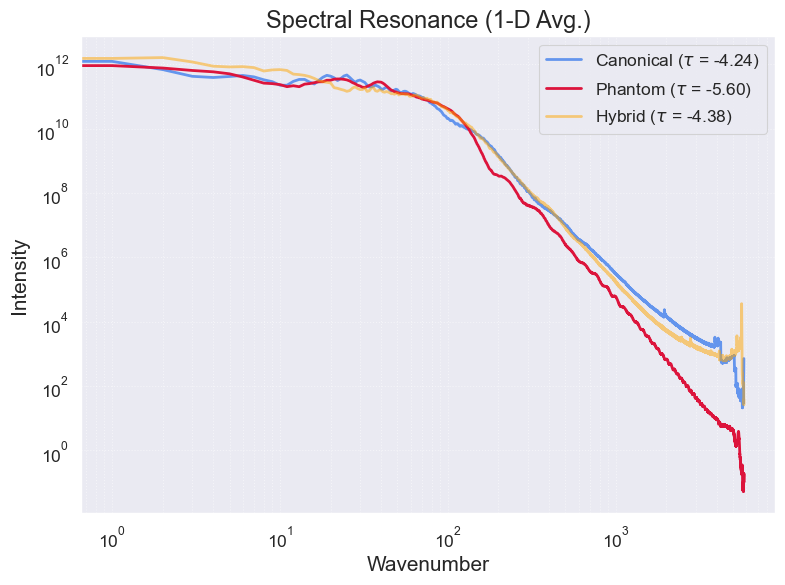

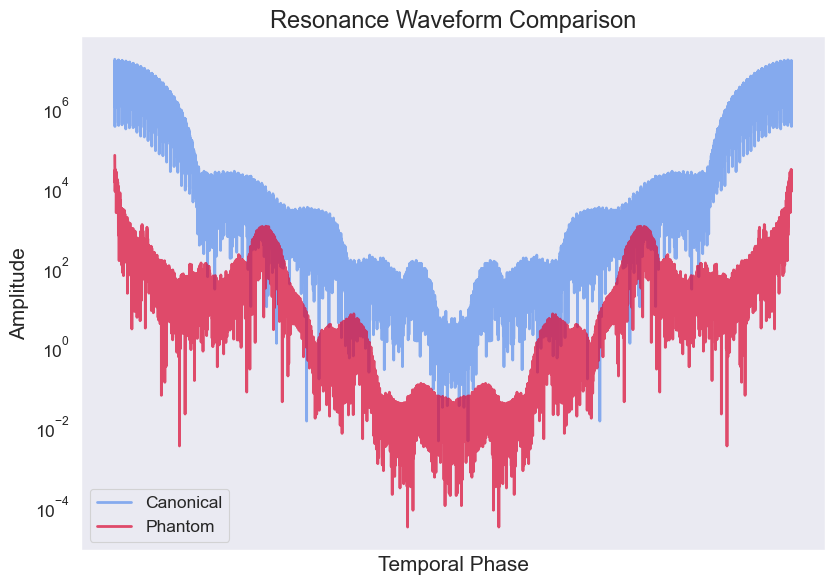

In [5]:
# KDE plot resolution
plot_points_1d = 2**17 if plot_resolution == 'high' else 2**10
plot_resolution_2d = 2**9 if plot_resolution == 'high' else 2**7

# misc parameters
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)
pd.set_option('display.max_columns',None)

##### load and isotropize data #####

# load and clean
ensemble_exponents = pd.read_csv(history_path)
ensemble_exponents = ensemble_exponents.drop_duplicates()
ensemble_exponents = ensemble_exponents[ensemble_exponents['fitness'] <= hbar/2].drop(['fitness'],axis=1)

# diversity
diversity_results = diversity_statistics(ensemble_exponents)
norm_entropies = diversity_results['efficiencies']

### isotropize ensemble
ensemble_isotropic, iso_params = hdim.isotropize(ensemble_exponents)
sigma_q_ensemble = quantum_bandwidth(ensemble_exponents, iso_params['W_zca_inv'], norm_entropies)

##### save topography architecture #####
np.savez_compressed('spacetime_data.npz', 
                    ensemble=ensemble_isotropic,
                    norm_entropies=norm_entropies,
                    iso_params=iso_params)
archive = np.load('spacetime_data.npz', allow_pickle=True)

ensemble_iso = archive['ensemble']
iso_params = archive['iso_params'].item()


#### topography assessment #####

# analyze coordinates
df_physics = analyze_coordinate(ensemble_exponents)
display(df_physics.head(5))

prob_1d, res_2d, ensemble_1d = pca_kde() # principal axes
spectral_analysis(ensemble_exponents,metric='nec') # spectral decompositiion
# pca_kde_accumulation()

## Analysis

\begin{table}[p]
\centering
\caption{Principal Axis Peak Probabilities}
\scriptsize
\setlength{\tabcolsep}{3pt}
\begin{tabular}{rc w{c}{1.2em} S[table-format=-1.1] S[table-format=1.1e2] || rc w{c}{1.2em} S[table-format=-1.1] S[table-format=1.1e2]}
\toprule
\textbf{x} & \textbf{Prob.} & \textbf{Reg.} & \textbf{$\omega$} & \textbf{NEC} & \textbf{x} & \textbf{Prob.} & \textbf{Reg.} & \textbf{$\omega$} & \textbf{NEC} \\
\midrule
-1.50 & 45.1\% & H. & 1.0 & 1.4e+58 & 0.24 & 61.8\% & C. & -1.0 & 0.0e+00 \\
-1.43 & 54.8\% & H. & 1.0 & 6.0e+55 & 0.29 & 59.5\% & C. & -1.0 & 0.0e+00 \\
-1.34 & 69.0\% & H. & 1.0 & 1.9e+51 & 0.31 & 58.1\% & C. & -1.0 & 0.0e+00 \\
-1.20 & 85.7\% & H. & 1.0 & 6.0e+47 & 0.36 & 57.4\% & C. & -1.0 & 0.0e+00 \\
-1.14 & 89.6\% & H. & 1.0 & 2.0e+45 & 0.37 & 57.0\% & C. & -1.0 & 0.0e+00 \\
-1.08 & 95.5\% & H. & 1.0 & 9.9e+42 & 0.39 & 57.2\% & C. & -1.0 & 0.0e+00 \\
-1.06 & 96.1\% & H. & 1.0 & 2.3e+42 & 0.42 & 56.8\% & C. & -1.0 & 0.0e+00 \\
-1.02 & 99.7\% & H. & 1.0 & 2.2e

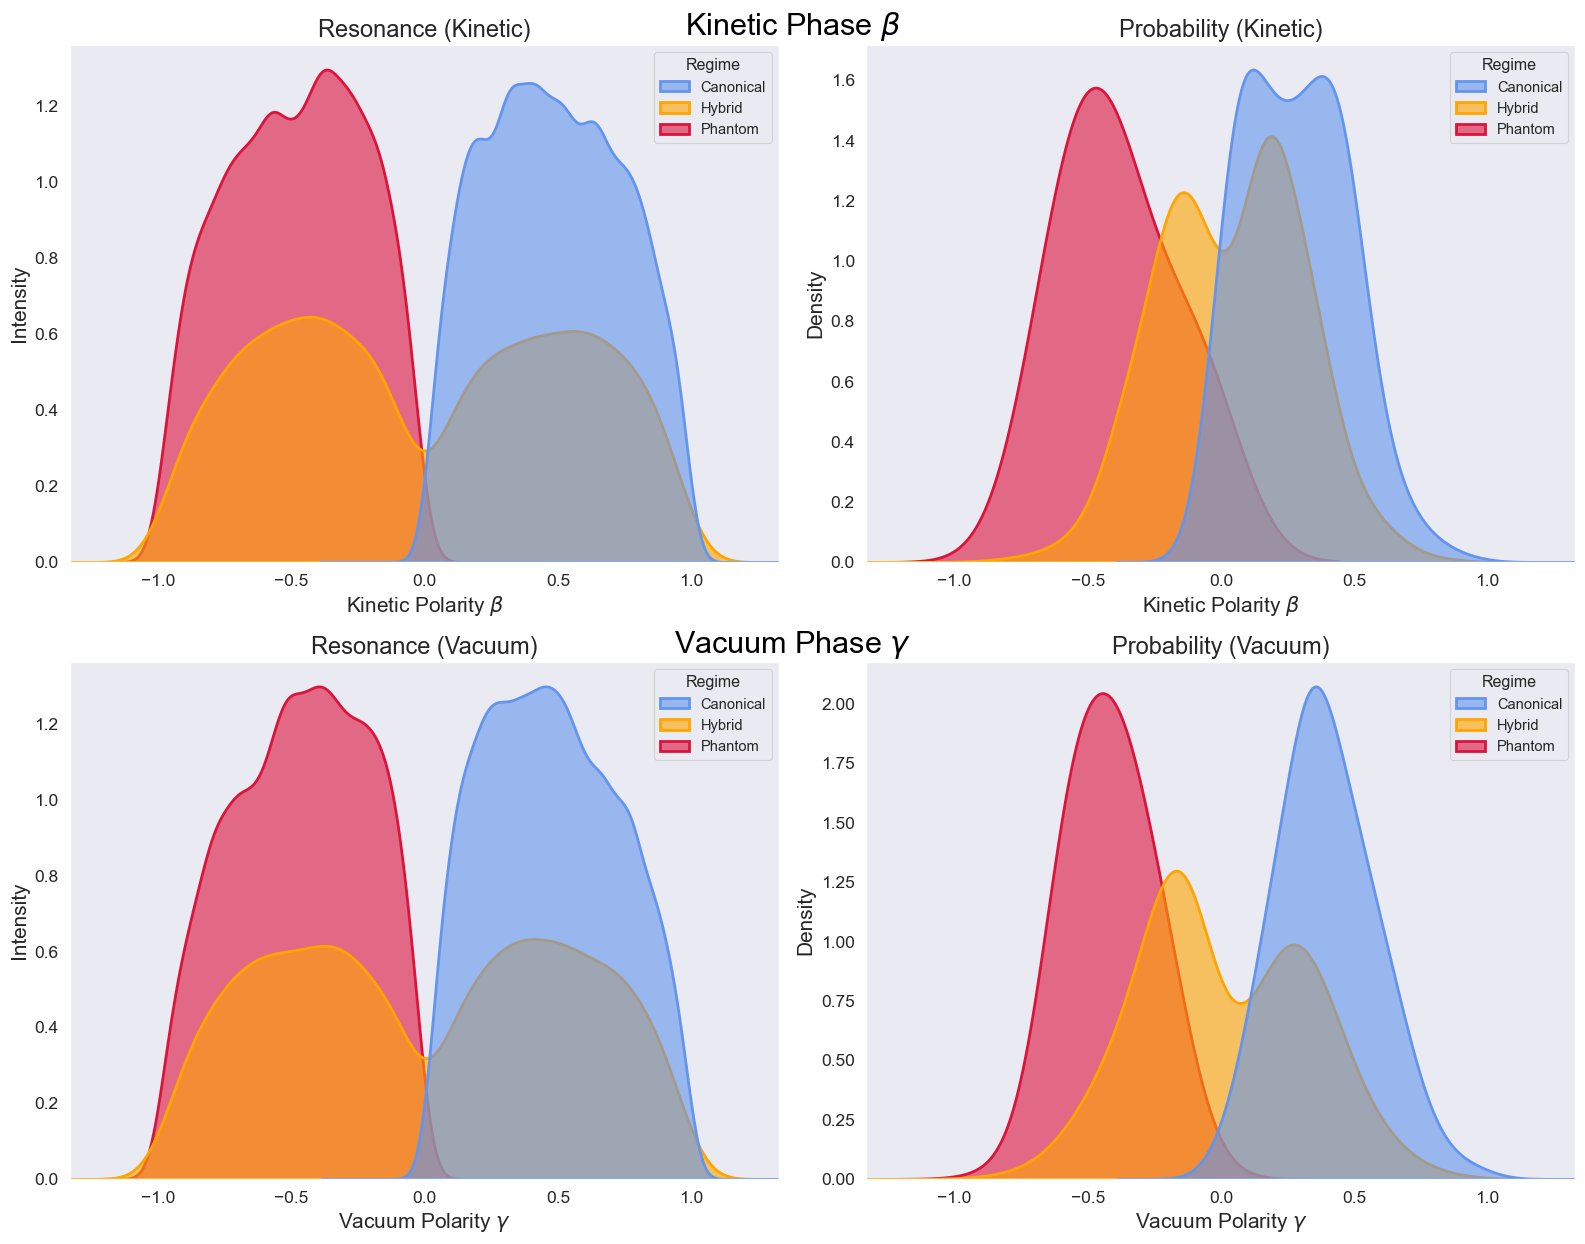


- Topography Analysis
Species                   | Resonance %  | Probability %
---------------------------------------------------------------------------
Dark Energy               | 43.2931     % | 67.8959     %
Stiff Fluid               | 34.1353     % | 23.6731     %
Exotic Fluid              | 22.2269     % | 8.4096      %
Superluminal Fluid        | 0.1406      % | 0.0128      %
Phantom Fluid             | 0.0159      % | 0.0058      %
Quintessence              | 0.1883      % | 0.0027      %

\begin{table}
\caption{Ensemble Physical Statistics}
\label{tab:physical_statistics}
\begin{tabular}{lr|rr|rr}
\toprule
 & Median & Mean & Stdev. & Min. & Max. \\
\midrule
$t$ & 2.55e-13 & 1.39e+15 & 2.22e+16 & 5.94e-44 & 8.42e+17 \\
$a$ & 1.98e+03 & 3.39e+24 & 3.71e+25 & 1.64e-35 & 9.96e+26 \\
$\dot{a}$ & 5.19e-53 & 6.81e+62 & 1.24e+65 & -2.30e+63 & 2.26e+67 \\
$\ddot{a}$ & -1.37e-09 & 3.81e+104 & 6.94e+106 & -2.55e+103 & 1.26e+109 \\
$\phi$ & -3.12e-33 & 3.44e+17 & 4.69e+20 & -9.53e+21 & 

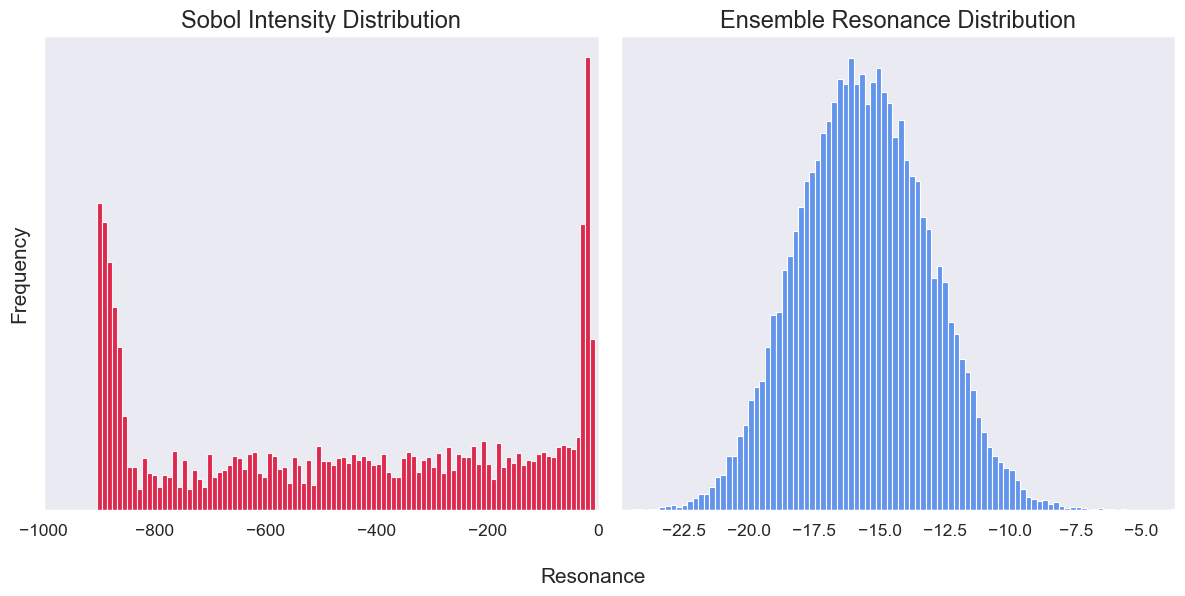

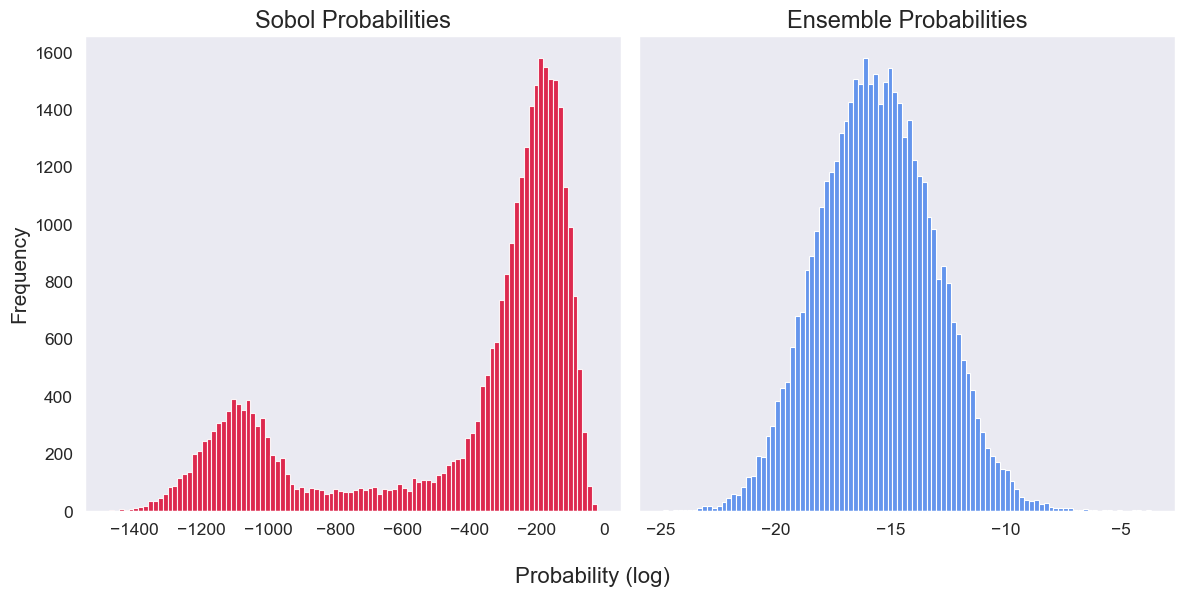

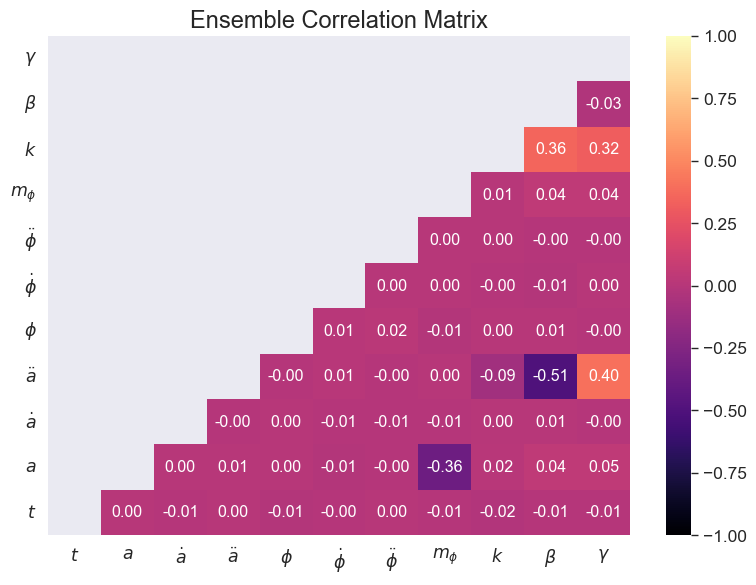

\begin{table}
\caption{Ensemble Covariance Matrix}
\label{tab:covariance}
\begin{tabular}{lrrrrrrrrrrr}
\toprule
 & $t$ & $a$ & $\dot{a}$ & $\ddot{a}$ & $\phi$ & $\dot{\phi}$ & $\ddot{\phi}$ & $m_{\phi}$ & $k$ & $\beta$ & $\gamma$ \\
\midrule
$t$ & 223.9 & 0.6 & -3.8 & 2.3 & -6.7 & -2.6 & 5.9 & -1.2 & -0.1 & -0.0 & -0.1 \\
$a$ & 0.6 & 197.8 & 2.4 & 7.1 & 2.1 & -8.9 & -1.0 & -66.6 & 0.1 & 0.3 & 0.3 \\
$\dot{a}$ & -3.8 & 2.4 & 1862.0 & -9.3 & 5.9 & -15.8 & -26.8 & -3.4 & 0.1 & 0.1 & -0.1 \\
$\ddot{a}$ & 2.3 & 7.1 & -9.3 & 8496.8 & -8.4 & 57.6 & -9.0 & 4.6 & -4.5 & -24.5 & 19.4 \\
$\phi$ & -6.7 & 2.1 & 5.9 & -8.4 & 1150.9 & 27.6 & 60.4 & -4.0 & 0.0 & 0.1 & -0.0 \\
$\dot{\phi}$ & -2.6 & -8.9 & -15.8 & 57.6 & 27.6 & 4922.0 & 14.4 & 2.5 & -0.2 & -0.3 & 0.0 \\
$\ddot{\phi}$ & 5.9 & -1.0 & -26.8 & -9.0 & 60.4 & 14.4 & 9543.5 & 2.8 & 0.1 & -0.1 & -0.1 \\
$m_{\phi}$ & -1.2 & -66.6 & -3.4 & 4.6 & -4.0 & 2.5 & 2.8 & 176.9 & 0.0 & 0.3 & 0.3 \\
$k$ & -0.1 & 0.1 & 0.1 & -4.5 & 0.0 & -0.2 & 0.1 & 0.0 

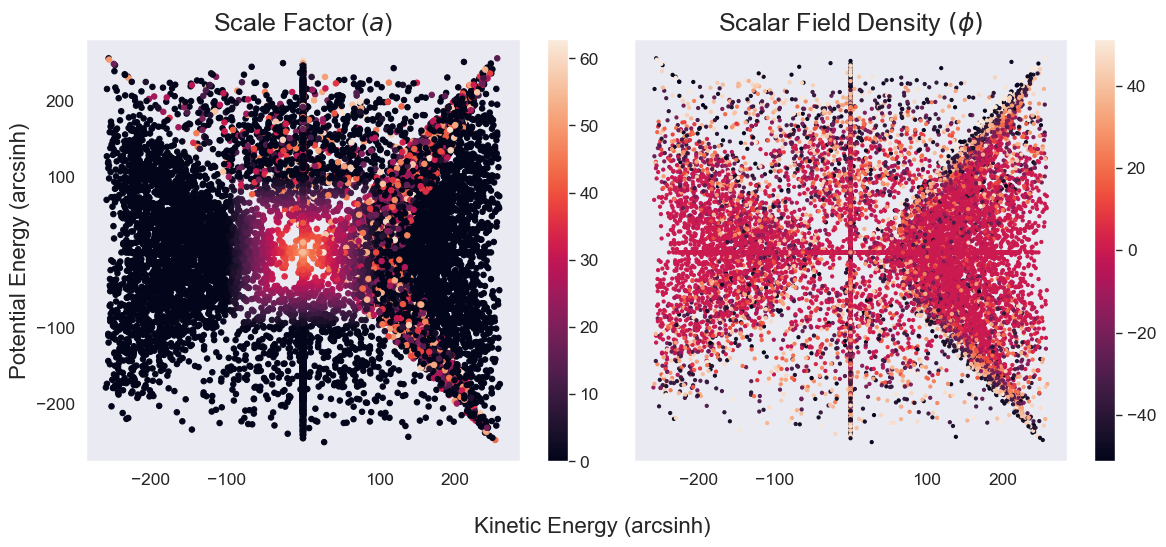

Generating Sobol samples (N=8,192, D=11).
Analyzing sensitivities.

Run time: 21.26s


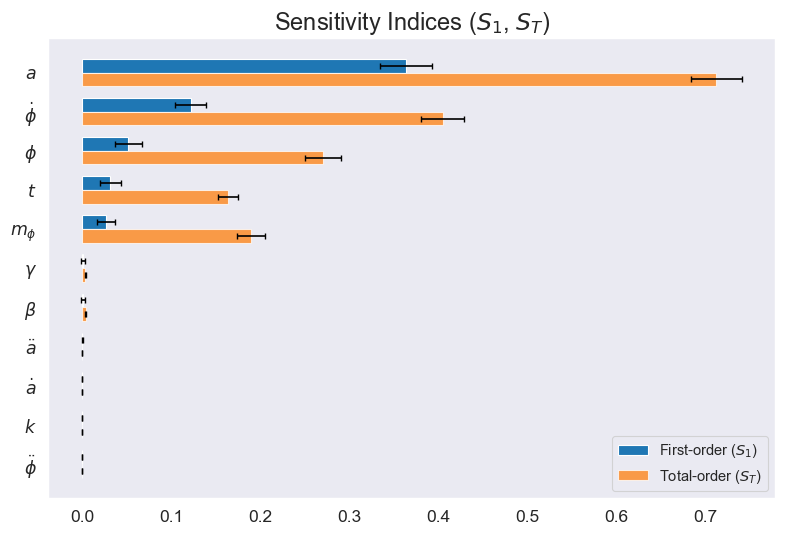

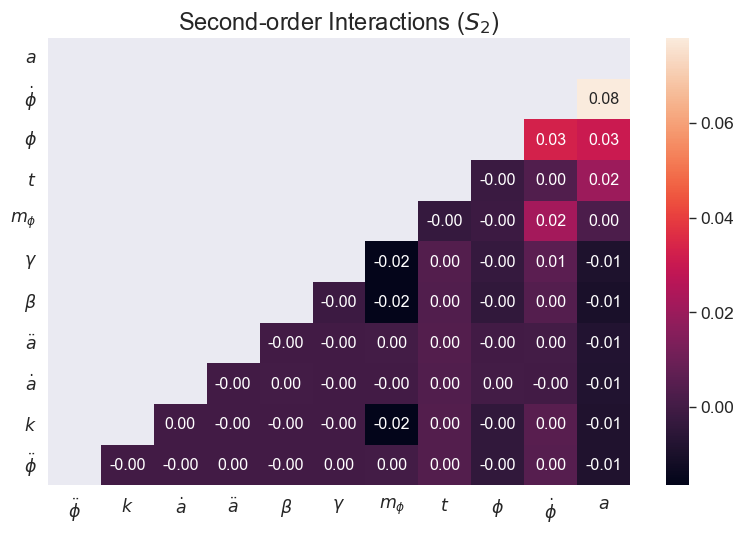

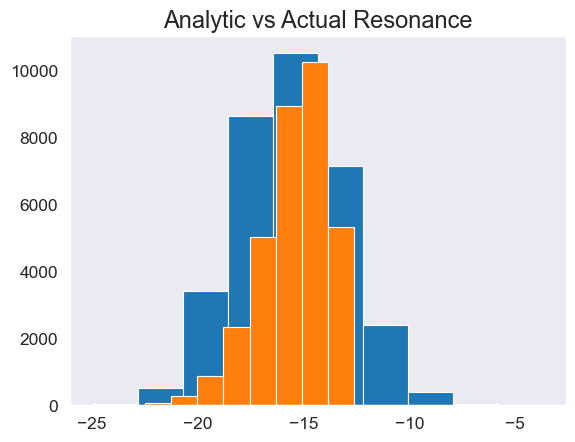

In [6]:
# classify_zeta
### analyze topography
peaks = peak_probabilities(prob_1d,ensemble_1d[0])
physical_stats = physical_statistics(ensemble_exponents)
sobol_distributions() # compare resonance of a sobol sequence
covariance_analysis(ensemble_exponents)
zeta_0 = expectation_value(df_physics[zeta_order_si + ['probability']]) # calculate expectation value of ensemble
plot_energy_scatter()
# hdim.analyze(ensemble_exponents)

# sensitivity analysis
n_sensitivity_samples = 2**13 if plot_resolution == 'high' else 2**10
bounds_iso_min = ensemble_isotropic.min(axis=0)
bounds_iso_max = ensemble_isotropic.max(axis=0)
bounds_iso = list(zip(bounds_iso_min, bounds_iso_max))
sens = hdim.sensitivity(
                    sensitivity_lorentzian_wrapper, kwargs={'ensemble': ensemble_isotropic}, 
                    bounds=bounds_iso, param_names=formatted_labels, n_samples=n_sensitivity_samples, 
                    calc_second_order=True, num_to_plot=n_dim, log_scale=False, verbose=True)

plt.hist(df_physics['intensity'],label='KDE')
plt.hist(df_physics['approx_resonance'],label='Analytic')
plt.title('Analytic vs Actual Resonance')
plt.show()

## Exotic Resonant Probabilities

In [7]:
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

################# median repolarized metrics #################
test_species = 'Exotic Fluid'
wormhole_species_raw = df_physics[df_physics['species']==test_species]
wormhole_species = encode_zeta(wormhole_species_raw[zeta_order_si])
wormholes_canonical = repolarize_species(test_species, 1.0, 1.0)
repol_probs = wormholes_canonical['probability'].values
print('Exotic canonical-repolarized probability:')
asymmetric_deviation(repol_probs)

##### minimum probability to exist at least once
max_time_quanta = 10**(bounds[0][1]-bounds[0][0])
min_proba_existing = -np.log(max_time_quanta)
print(f'\nResonant probability is negligible below: e^{min_proba_existing:.0f}')

# proportion resonating above minimum threshold to exist once
resonant_existing = (repol_probs >= min_proba_existing)  # (t_H / t_p)^-11
resonant_occurring = np.sum(resonant_existing) / len(wormhole_species)
print(f'\n- Proportion resonating above existence threshold: {resonant_occurring:.3f}')


# # long runtime:
# ################# identify optimal wormhole phase #################
# n_iter = 20 if plot_resolution == 'high' else 3
# print(f'\nFinding optimal phase for species {test_species}:')
# opt_phase, opt_phase_err = find_natural_phase(test_species,n_iter=3)
# wormholes_typical = repolarize_species(test_species, -0.15, 0.22) # using optimal phase (-0.15, 0.22)
# print('\nExotic optimal-repolarized probability:')
# asymmetric_deviation(wormholes_typical['probability'].values)

Exotic canonical-repolarized probability:
Asymmetric Deviation:
- Median: -144
- Superscript (+): 78
- Subscript (-): -140

Resonant probability is negligible below: e^-141

- Proportion resonating above existence threshold: 0.485


## Exotic Fluctuation Probabilities
- Uncomment bottom half to generate new optimal-phase wormhole coordinates for tunneling analysis

In [10]:

### wormhole tunneling comparison
print('Median vs Random exotic fluid:')
random.seed(43) # record 43 visually best
wormhole_median = np.array(np.median(wormhole_species,axis=0)) # median wormhole
wormhole_random = random.choice(wormhole_species) # random wormhole
results = fluctuation_analysis(wormhole_median, wormhole_random, path_steps=100)

### plot wormhole resonant force #####
print('\nProbability gradient phase map:')
plot_force_field(wormhole_median)

# # takes a while to fluctuate them all:
# ################# ensemble exotic fluctuations into canonical phase #################
print(f'\n- Fluctuating {len(wormhole_species)} ensemble exotic fluid coordinates to canonical phase:')

# collect probabilities for each coordinate in ensemble
tunnel_probs = []
for i, zeta_w in enumerate(wormhole_species):
    if i % (len(wormhole_species) // 10) == 0:
        print(int(i / len(wormhole_species) * 100), '%')
    # set destination (canonical phase)
    zeta_dest = zeta_w.copy()
    zeta_dest[9], zeta_dest[10] = 1, 1  # set beta=1, gamma=1
    
    # run analysis
    stats = fluctuation_analysis(zeta_w, zeta_dest, verbose=False)
    tunnel_probs.append(stats['probability'])

# tunneling probabilities
tunnel_probs = np.array(tunnel_probs)
print('\nFluctuation probability into canonical phase:')
asymmetric_deviation(tunnel_probs)


# identify states with probability below 1 occurence in hubble age
successful_tunnels = (tunnel_probs >= min_proba_existing)  # (t_H / t_p)^-11

# ratio of successful occurrences
tunnels_occurring = np.sum(successful_tunnels) / len(wormhole_species)
print(f'- Proportion of fluctuating into our universe at least once: {tunnels_occurring:.3f}')


# Fluctuation probability into canonical phase:
# Asymmetric Deviation:
# - Median: -320
# - Superscript (+): 110
# - Subscript (-): -266

# Resonant probability is negligible below: e^-141

# - Proportion of exotic fluid resonating above existence threshold: 0.485
# - Expected probability of fluctuating into our universe at least once: 0.016


Fluctuation probability into canonical phase:
Asymmetric Deviation:
- Median: -319
- Superscript (+): 109
- Subscript (-): -268
- Proportion of fluctuating into our universe at least once: 0.016


## Resonant Fluctuations

Proportion of exotic states both fluctuating and resonating: 0.00042783799201369084


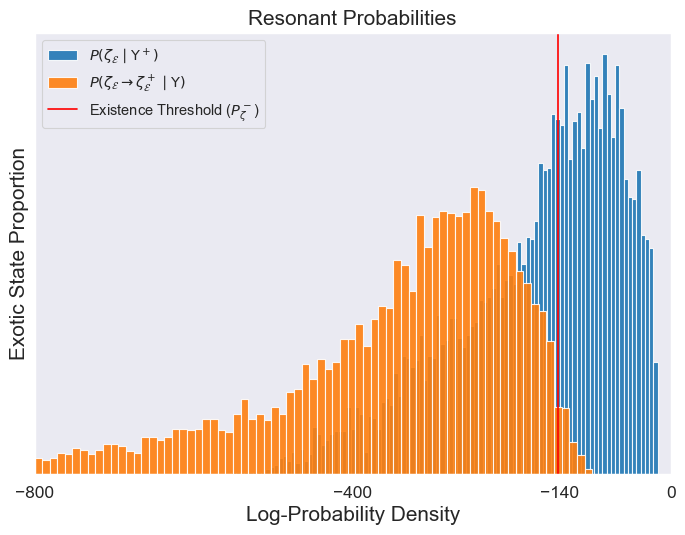

In [11]:
################ resonant fluctuations
resonant_fluctuations = (tunnel_probs >= min_proba_existing) & (repol_probs >= min_proba_existing)
resonant_fluctuations_proportion = np.sum(resonant_fluctuations) / len(wormhole_species)
print(f'Proportion of exotic states both fluctuating and resonating: {resonant_fluctuations_proportion}')



fig, ax = plt.subplots(1, 1, figsize=(7,5.5))

ax.hist(repol_probs,alpha=0.9, bins=100, density=True, label=r'$P(\zeta_\mathcal{E} \mid \Upsilon^+)$')
ax.hist(tunnel_probs,alpha=0.9, bins=2000, density=True, label=r'$P(\zeta_\mathcal{E} \to \zeta_\mathcal{E}^+ \mid \Upsilon)$')
ax.axvline(min_proba_existing, color='red', label=r'Existence Threshold ($P^-_\zeta$)')
ax.set_title('Resonant Probabilities', fontsize=15)
ax.set_ylabel('Exotic State Proportion')
ax.set_xticks([-800,-400,-140,0])
ax.set_yticks([])
ax.set_xlabel('Log-Probability Density')
ax.set_xlim([-800, 0])
ax.legend()

plt.tight_layout()
plt.savefig('plots/exotic_probabilities.png')
plt.show()

# proportion of states both fluctuating and resonating: 0.00043

## Analytic Approximation (Symbolic Regression)
- Uncomment to generate analytic expressions

In [ ]:
# from gplearn.genetic import SymbolicRegressor
# from gplearn.functions import make_function
# from sklearn.metrics import r2_score, mean_absolute_error
# from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
# from sklearn.linear_model import LinearRegression

# ### split data
# df_physics_clean = df_physics[df_physics['intensity'].between(df_physics['intensity'].quantile(0.05), 
#                                                               df_physics['intensity'].quantile(0.95))] # filter 2 stdevs for easier training
# y = df_physics_clean['intensity'].copy().values.reshape(-1,1)
# y_scaled = (y - y.mean())/y.std() # shifting to 0 mean

# # scale (X)
# X_raw = encode_zeta(df_physics_clean[zeta_order_si])
# keep_indices = [3, 7, 8, 9, 10] # other variables are redundant
# X_scaled = X_raw[:, keep_indices]
# a_dd_max = np.max(np.abs(X_scaled[:, 0]))
# X_scaled[:, 0] = X_scaled[:, 0] / a_dd_max # min-max scale a_dd
# m_max = np.max(np.abs(X_scaled[:, 1]))
# X_scaled[:, 1] = X_scaled[:, 1] / m_max # min-max scale a_dd 

# # shapes for gplearn
# def _lorentzian(x):
#     return 1.0 / (1.0 + np.square(x))
# def _square(x):
#     return np.square(x)
# def _cube(x):
#     return np.power(x,3)
# def _quartic(x):
#     return np.power(x,4)
# def _abs(x):
#     return np.abs(x)
# def _sqrt(x):
#     return np.sqrt(np.abs(x))

# # cconvert to gplearn function objects
# sqrt_func = make_function(function=_sqrt, name='sqrt', arity=1)
# square_func = make_function(function=_square, name='sq', arity=1)
# cube_func = make_function(function=_cube, name='cb', arity=1)
# quartic_func = make_function(function=_quartic, name='qt', arity=1)
# lorentz_func = make_function(function=_lorentzian,name='lor', arity=1)

# # establish symbolic regression architecture
# est_gp = SymbolicRegressor(
#     population_size=2**14, # 2**14
#     generations=20, # 20
#     tournament_size=2**5, # 2**7
#     init_depth=(2,3),
#     parsimony_coefficient=0.005, # 0.002
#     max_samples=1.0,
#     const_range=(-1,1),
#     function_set=('add', 'sub', 'mul', 'div', square_func, cube_func, lorentz_func, quartic_func),
#     feature_names=['a_dd', 'm', 'k', 'b', 'g'],
#     verbose=1,
#     n_jobs=-1
# )
# # fit to the ensemble
# est_gp.fit(X_scaled, y_scaled)

# # print the resulting symbolic expression
# print(est_gp._program)

# y_pred_scaled = est_gp.predict(X_scaled)
# y_pred = (y_pred_scaled * y.std()) + y.mean()
# print(f'R-squared: {r2_score(y, y_pred)}')

# plt.scatter(y, y_pred)
# plt.title('Genetic Equation Predictions vs Actuals')
# plt.xlabel('Actual')
# plt.ylabel('Predicted')
# plt.show()


# # evaluate all programs
# all_programs = est_gp._programs[-1]
# refined_stats = []

# print("- Evaluating all modes:")
# for idx, program in enumerate(all_programs):
#     if program is None:
#         continue
        
#     # raw symbolic predictions
#     y_shape = program.execute(X_scaled).reshape(-1, 1)
    
#     # invalid output cleaning
#     if np.any(np.isnan(y_shape)) or np.any(np.isinf(y_shape)):
#         continue
    
#     # linear refinement
#     refiner = LinearRegression().fit(y_shape, y)
#     y_final = refiner.predict(y_shape)
    
#     # calculate scores
#     r2 = r2_score(y, y_final)
#     mae = mean_absolute_error(y, y_final)
#     refined_stats.append({
#         'index': idx,
#         'program_obj': program,
#         'y_pred': y_final,
#         'R2': r2,
#         'MAE': mae,
#         'Length': program.length_,
#         'Formula': str(program)
#     })

# # sort by R^2
# results_df = pd.DataFrame(refined_stats)
# results_df = results_df.sort_values(by=['R2', 'MAE'], ascending=[False, True]).reset_index(drop=True)

# # display top values
# print('\nTop 10 Equations (by R^2)')
# # reformat
# pd.options.display.max_colwidth = 100 
# print(results_df[['R2', 'MAE', 'Length', 'Formula']].head(10))

# # plot top 3
# for i in range(min(3, len(results_df))):
#     row = results_df.iloc[i]
#     plt.figure(figsize=(6, 4))
#     plt.scatter(y, row['y_pred'], alpha=0.3, s=2, color='darkorange' if i==0 else 'royalblue')
#     plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', alpha=0.5, label='Perfect Fit')
#     plt.title(f"Rank {i+1} | Refined R2: {row['R2']:.4f}")
#     plt.xlabel("Actual Intensity")
#     plt.ylabel("Refined GP Prediction")
#     plt.legend()
#     plt.grid(True, alpha=0.3)
#     plt.show()

### Test Analytic Function

Analytic approximation:
- R^2: 0.553
- MAE: 1.2646



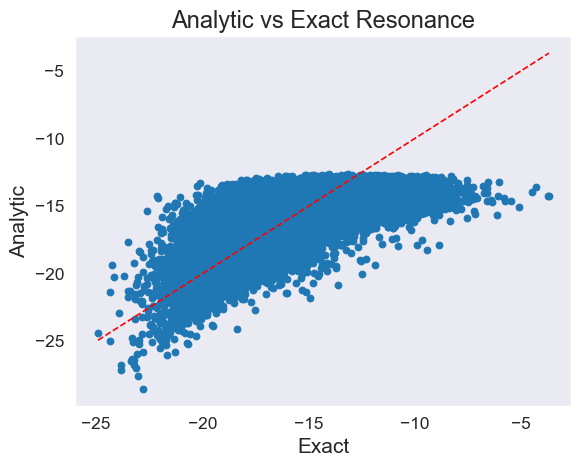

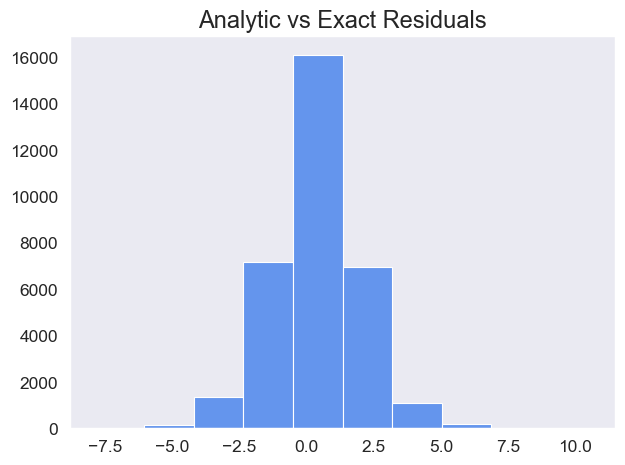

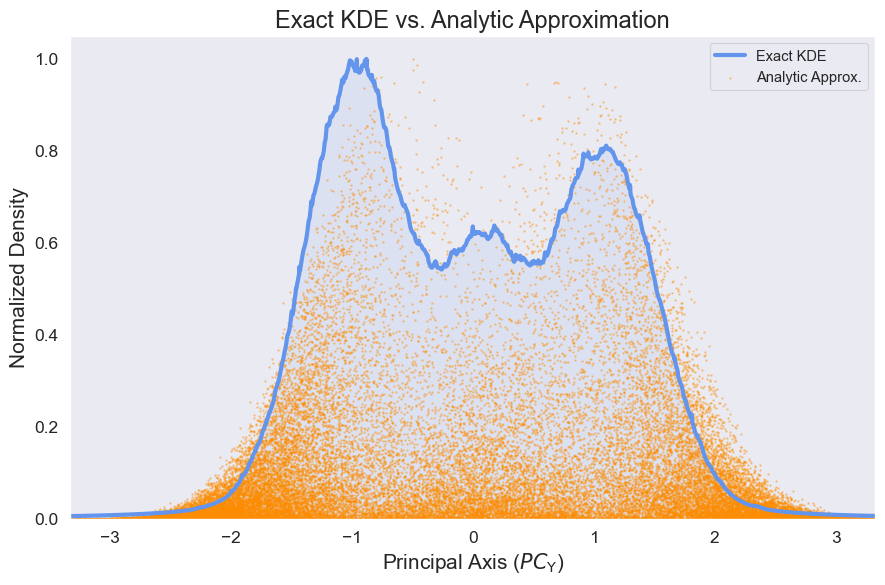

In [12]:
from sklearn.metrics import r2_score, mean_absolute_error

### split data
ups_kde = df_physics['intensity'].copy().values.reshape(-1,1)

# scale (X)
X_raw = encode_zeta(df_physics[zeta_order_si])
keep_indices = [3, 7, 8, 9, 10] # other variables are redundant
X_scaled = X_raw[:, keep_indices]
a_dd_max = np.max(np.abs(X_scaled[:, 0]))
X_scaled[:, 0] = X_scaled[:, 0] / a_dd_max # min-max scale a_dd # REVERT TO 0 IF REMOVING MASS
m_max = np.max(np.abs(X_scaled[:, 1]))
X_scaled[:, 1] = X_scaled[:, 1] / m_max # min-max scale a_dd 

a_dd = X_scaled[:,0].flatten()
m = X_scaled[:,1].flatten()
k = X_scaled[:,2].flatten()
b = X_scaled[:,3].flatten()
g = X_scaled[:,4].flatten()

# map indices to variable names (X_9 is column 9, etc)
def lor(x): return 1.0 / (1.0 + np.square(x))
def cb(x):  return np.power(x, 3)
def sq(x):  return np.square(x)
def dw(x):
    return np.square(np.square(x) - 1)
def qt(x): return np.power(x,4)
def test_analytic_approximation():
    # analytic_skeleton = (-(b**2+g**2+k**2) + b*(g-k) + lor(a_dd**4/(m))).reshape(-1,1) # skeleton (without constants)
    raw_shape = ((-1/2)*(b**2 + g**2 + k**2) + (1/3)*b*(g-k) + lor(a_dd**4 / m)) # (with constants)
    ups_analytical = (2 * np.pi) * (raw_shape - 3)

    # result metrics
    residual = ups_kde.flatten() - ups_analytical
    r2 = r2_score(ups_kde, ups_analytical)
    mae = mean_absolute_error(ups_kde, ups_analytical)

    print(f"- R^2: {r2:.3f}")
    print(f"- MAE: {mae:.4f}")

    return ups_analytical, residual


def plot_analytic_vs_kde(ensemble_zero_1d, ups_vals, x_range_kde, probability_kde):
    '''
    Visualizes the analytic function distribution compared to the exact KDE.
    '''
    # convert resonance to probability
    prob_analytical = np.exp(ups_vals)
    
    # normalize
    prob_analytical /= np.max(prob_analytical)

    # plot exact KDE values
    plt.figure(figsize=(9, 6))
    
    plt.plot(x_range_kde.flatten(), probability_kde, color='cornflowerblue', 
             lw=3, label='Exact KDE', zorder=2)
    plt.fill_between(x_range_kde.flatten(), probability_kde, color='cornflowerblue', alpha=0.1)
    
    # plot analytic approximation
    plt.scatter(ensemble_zero_1d.flatten(), prob_analytical, color='darkorange', 
                s=1, alpha=0.33, label='Analytic Approx.', zorder=1)

    # average over bins
    df_plot = pd.DataFrame({'x': ensemble_zero_1d.flatten(), 'y': prob_analytical})

    plt.title("Exact KDE vs. Analytic Approximation")
    plt.xlabel(r"Principal Axis ($PC_\Upsilon$)")
    plt.ylabel("Normalized Density")
    plt.legend()
    plt.xlim(-3.33, 3.33)
    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.savefig('plots/symbolic_distribution.png')
    plt.show()

# compare analytical to KDE resonances
print('Analytic approximation:')
ups_vals, res = test_analytic_approximation()

# ### plot
print()
# scatter of prediction vs analytic
plt.scatter(ups_kde, ups_vals)
plt.plot([ups_kde.min(),ups_kde.max()], [ups_kde.min(),ups_kde.max()], 'r--')
plt.title('Analytic vs Exact Resonance')
plt.xlabel('Exact')
plt.ylabel('Analytic')
plt.show()

# residuals
plt.hist(res, color='cornflowerblue')
plt.title('Analytic vs Exact Residuals')
plt.tight_layout()
plt.savefig('plots/symbolic_residuals.png')
plt.show()


# compare to PCA
ensemble_zero_1d = ensemble_1d[1]
x_range_kde = prob_1d[0]
probability_kde = prob_1d[1]
plot_analytic_vs_kde(ensemble_zero_1d, ups_vals, x_range_kde, probability_kde)

## Toppographic Trajectories: Harmonic Oscillation


Median coordinate:
- Resonant force: [ 24.97674989  76.98529237   0.          -1.00000159 -53.65696233
   0.           1.00001015  52.65684087  -3.3285037    2.65672704
  67.09496161]
- Gradient (Resonance): [ 24.97674989  75.98529934   0.           0.         -50.656949
   0.           0.          50.65683768   0.           0.
  64.54658399]
- Gradient (Physical): [ 0.         -0.99999303  0.          1.00000159  3.00001334  0.
 -1.00001015 -2.00000318  3.3285037  -2.65672704 -2.54837762]

Evaluating topographic trajectory.


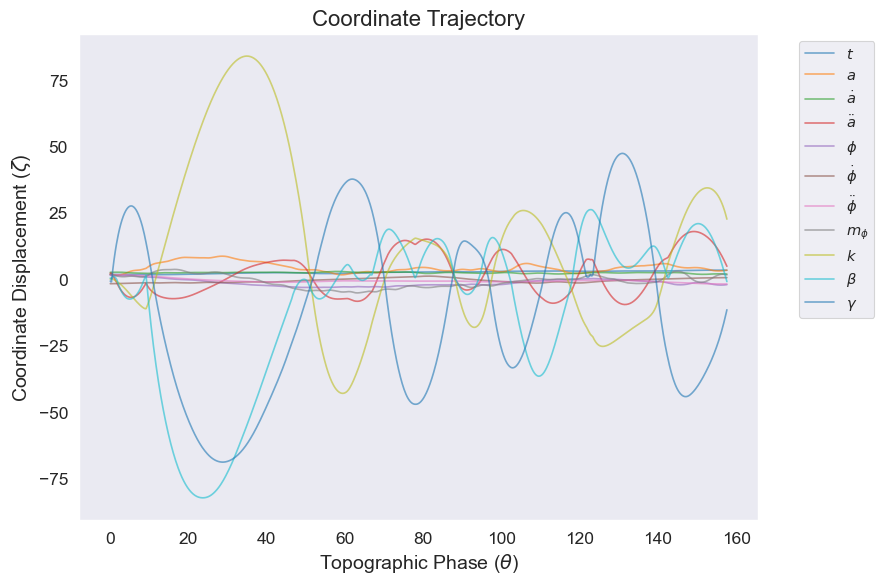

In [13]:
## median coordinate ~= expected value
zeta_curr = encode_zeta(np.median(df_physics[zeta_order_si],axis=0)) # calculate expectation value of ensemble
net_force, grad_res, grad_phys = resonant_force(zeta_curr)
print()

print('Median coordinate:')
print(f'- Resonant force: {net_force}')
print(f'- Gradient (Resonance): {grad_res}')
print(f'- Gradient (Physical): {grad_phys}\n')

# initialize constants
I_11 = np.eye(n_dim)
inv_covariance = iso_params['W_zca_inv'] # \Sigma^{-1}
inv_sqrt_covariance = iso_params['W_zca']  # \Sigma^{-1/2}

dt = 0.15777777699999998 # for isotropic
n_steps = 1000

# initialize variables
zeta_curr = encode_zeta(np.mean(df_physics[zeta_order_si], axis=0))
v_curr = np.zeros(11) # zero initial velocity

coordinate_history = []
print('Evaluating topographic trajectory.')
for i in range(0, n_steps):
    h_zeta = quantum_bandwidth(zeta_curr, iso_params['W_zca_inv'], norm_entropies)[0]

    # restoring
    net_force, _, _ = resonant_force(zeta_curr)
    restoring_force = net_force.flatten() 

    # dissipating
    damping_matrix = (h_zeta) * inv_sqrt_covariance
    damping_force = np.dot(damping_matrix, v_curr)

    # acceleration
    acceleration = restoring_force - damping_force

    # flatten and add to array
    coordinate_history.append(np.array(zeta_curr).flatten().copy())
    
    # symplectic integration updates
    v_curr = v_curr + acceleration * dt  
    zeta_curr = zeta_curr + v_curr * dt

coordinate_history = np.vstack(coordinate_history)
theta_axis = np.arange(n_steps) * dt

isotropic_coordinates = []
for i in coordinate_history:
    isotropic_coordinates += [isotropize_zeta(i)]

isotropic_coordinates = np.array(isotropic_coordinates)
# plot trajectories
plt.figure(figsize=(9, 6))
for d in range(11):
    sns.lineplot(x=theta_axis, y=isotropic_coordinates[:, d], alpha=0.6, label=list(plot_label_map.values())[d])
    
plt.title('Coordinate Trajectory', fontsize=16)
plt.xlabel(r'Topographic Phase ($\theta$)', fontsize=14)
plt.ylabel(r'Coordinate Displacement ($\zeta$)', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('plots/cosmic_oscillation.png')
plt.show()